In [3]:
import os
import gc
import glob
import pandas as pd
from obspy import read, Stream
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER JALUR DATA LOKAL (Sesuaikan Folder SSD Mac Anda)
# ==============================================================================
INPUT_GABUNGAN_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/katalog_radar_dll/HYBRID_EARTHQUAKE_CATALOG_2001_2024.csv'
BASE_DATASET_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai'

OUTPUT_EVENT_DIR = os.path.join(BASE_DATASET_DIR, 'event_3c_7s')
OUTPUT_NOISE_DIR = os.path.join(BASE_DATASET_DIR, 'noise_3c_7s')
PATH_LABEL_CATALOG_CSV = os.path.join(BASE_DATASET_DIR, 'dataset_manifest_le_no.csv')

# Parameter Standarisasi Dimensi Matriks Input AI
TARGET_SAMPLING_RATE = 100.0   # Resample ke 100 Hz
TARGET_DURATION_SEC = 7.0      # Jendela wajib 7 detik penuh (700 Titik Sampel)
FREQ_MIN_HZ = 1.0              # Batas bawah filter bandpass (Hz)
FREQ_MAX_HZ = 45.0             # Batas atas filter bandpass (Hz)
TAPER_PERCENTAGE = 0.05        # Taper 5% untuk meredam riak ujung sinyal

def filter_advanced_channel_band(st):
    """ Menyaring interferensi kode lokasi ganda atau multi-band sensor """
    if len(st) <= 3:
        return st
    bh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("BH")]
    if len(bh_traces) == 3: return Stream(traces=bh_traces)
    hh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("HH")]
    if len(hh_traces) == 3: return Stream(traces=hh_traces)
    st_fallback = Stream()
    components_seen = set()
    for tr in st:
        comp_letter = tr.stats.channel[-1].upper()
        if comp_letter not in components_seen:
            components_seen.add(comp_letter)
            st_fallback.append(tr)
        if len(st_fallback) == 3: break
    return st_fallback

def process_split_and_label_le_no(file_path):
    try:
        st_raw = read(file_path)
        
        # 🛡️ PEMBERSIHAN KUALITAS KOMPONENT N, Z, E
        st_master = filter_advanced_channel_band(st_raw)
        if len(st_master) != 3:
            del st_raw, st_master
            return None
            
        # 🛡️ PROSES EKSEKUSI PREPROCESSING DIGITAL GEORADAR SEISMK
        for tr in st_master:
            if tr.stats.sampling_rate != TARGET_SAMPLING_RATE:
                tr.resample(target_sampling_rate=TARGET_SAMPLING_RATE, no_filter=False)
            tr.detrend(type='demean')
            tr.detrend(type='linear')
            tr.taper(max_percentage=TAPER_PERCENTAGE, type='cosine')
            tr.filter(type='bandpass', freqmin=FREQ_MIN_HZ, freqmax=FREQ_MAX_HZ, corners=4, zerophase=True)
                
        t_arrival = st_master[0].stats.starttime + 15
        
        # ─── 📑 SEGMEN LE: DATA GEMPA 7 DETIK ───
        st_event = st_master.copy()
        event_start = t_arrival
        event_end = event_start + TARGET_DURATION_SEC
        st_event.trim(starttime=event_start, endtime=event_end, pad=False)
        for tr in st_event:
            expected_pts = int(TARGET_DURATION_SEC * TARGET_SAMPLING_RATE)
            tr.data = tr.data[:expected_pts]
            tr.stats.npts = expected_pts
            
        # ─── 📑 SEGMEN NO: DATA NOISE STERIL 7 DETIK ───
        st_noise = st_master.copy()
        noise_start = t_arrival - 8  
        noise_end = t_arrival - 1    
        st_noise.trim(starttime=noise_start, endtime=noise_end, pad=False)
        for tr in st_noise:
            expected_pts = int(TARGET_DURATION_SEC * TARGET_SAMPLING_RATE)
            tr.data = tr.data[:expected_pts]
            tr.stats.npts = expected_pts

        # ─── 📦 WRITE FISIK KE SSD MAC BAPAK ───
        relative_path = os.path.relpath(file_path, INPUT_GABUNGAN_DIR)
        final_event_path = os.path.join(OUTPUT_EVENT_DIR, relative_path)
        os.makedirs(os.path.dirname(final_event_path), exist_ok=True)
        st_event.write(final_event_path, format="MSEED")
        
        final_noise_path = os.path.join(OUTPUT_NOISE_DIR, relative_path)
        os.makedirs(os.path.dirname(final_noise_path), exist_ok=True)
        st_noise.write(final_noise_path, format="MSEED")
        
        records = [
            {"File_Path": final_event_path, "Category": "Earthquake", "Label": "LE"},
            {"File_Path": final_noise_path, "Category": "Ambient_Noise", "Label": "NO"}
        ]
        del st_raw, st_master, st_event, st_noise
        return records
    except Exception:
        return None

def run_mass_splitting_pipeline():
    print("="*80)
    print("🚀 STARTING: MASSIVE FILTERED DATASET SPLITTER & LABELER PIPELINE")
    print("="*80)
    
    # Validasi keberadaan folder input hulu demi mencegah silent error
    if not os.path.exists(INPUT_GABUNGAN_DIR):
        print(f"❌ GALAT FATAL: Jalur direktori utama tidak ditemukan di SSD: {INPUT_GABUNGAN_DIR}")
        return

    os.makedirs(BASE_DATASET_DIR, exist_ok=True)
    if os.path.exists(PATH_LABEL_CATALOG_CSV): os.remove(PATH_LABEL_CATALOG_CSV)
        
    print("⏳ Memuat indeks Katalog Hibrida Master untuk mengunci gerbang filter...")
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    col_master_id = next((c for c in df_catalog.columns if 'id' in c.lower()), 'Event_ID')
    valid_catalog_set = set(df_catalog[col_master_id].astype(str).unique())
    del df_catalog
    gc.collect()
    
    print("📂 Menyisir folder SSD untuk mendaftar file master...")
    search_path = os.path.join(INPUT_GABUNGAN_DIR, "**", "*.mseed")
    all_files = glob.glob(search_path, recursive=True)
    total_files = len(all_files)
    
    # 🔥 DIAGNOSTIK DARURAT: Jika total berkas nol, langsung berikan peringatan tertulis!
    if total_files == 0:
        print("❌ GALAT: Python mendeteksi 0 file MiniSEED di folder Anda. Periksa kembali koneksi Extreme SSD.")
        return
        
    print(f"✅ Sukses Mendata {total_files:,} berkas master gabungan untuk diproses.")
    
    chunk_records = []
    success_count = 0
    skipped_anomali_count = 0
    
    # Jalankan perulangan utama dengan indikator visual progress bar di sel Jupyter
    with tqdm(total=total_files, unit="file", desc="Processing Waveforms") as pbar:
        for idx, file_path in enumerate(all_files, 1):
            folder_event_id = os.path.basename(os.path.dirname(file_path))
            
            if str(folder_event_id) not in valid_catalog_set:
                skipped_anomali_count += 1
                pbar.update(1)
                continue
                
            result = process_split_and_label_le_no(file_path)
            if result:
                success_count += 1
                chunk_records.extend(result)
                
            pbar.update(1)
            pbar.set_postfix({"Valid": success_count, "Skipped_Anomali": skipped_anomali_count})
            
            if idx % 3000 == 0:
                if chunk_records:
                    df_chunk = pd.DataFrame(chunk_records)
                    df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                                    header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
                    chunk_records.clear()
                gc.collect()
                
    if chunk_records:
        df_chunk = pd.DataFrame(chunk_records)
        df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                        header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
        chunk_records.clear()
        
    gc.collect()
    print("\n" + "="*60)
    print("🏁 PROSES SELESAI: DATASET TERLABEL BERHASIL DIPRODUKSI")
    print("="*60)
    print(f"✅ Pasangan Dataset Berhasil Diproduksi : {success_count:,} pasang berkas.")
    print(f"🛡️  Berkas Anomali Berhasil Dieliminasi  : {skipped_anomali_count:,} file.")
    print(f"📦 Hasil Katalog CSV Tersimpan di        : {PATH_LABEL_CATALOG_CSV}")
    print("="*60)

# ==============================================================================
# 🔥 GERBANG UTAMA EKSEKUSI PROGRAM (DIUMPAN SECARA TEGAS)
# ==============================================================================
if __name__ == "__main__":
    run_mass_splitting_pipeline()

🚀 STARTING: MASSIVE FILTERED DATASET SPLITTER & LABELER PIPELINE
⏳ Memuat indeks Katalog Hibrida Master untuk mengunci gerbang filter...
📂 Menyisir folder SSD untuk mendaftar file master...
✅ Sukses Mendata 59,501 berkas master gabungan untuk diproses.


Processing Waveforms:  64%|██████▍   | 38369/59501 [01:04<00:36, 574.93file/s, Valid=0, Skipped_Anomali=28]/opt/homebrew/Caskroom/miniforge/base/envs/waveform/lib/python3.10/site-packages/obspy/io/mseed/core.py:1034: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)
Processing Waveforms: 100%|██████████| 59501/59501 [01:48<00:00, 547.86file/s, Valid=734, Skipped_Anomali=73]



🏁 PROSES SELESAI: DATASET TERLABEL BERHASIL DIPRODUKSI
✅ Pasangan Dataset Berhasil Diproduksi : 734 pasang berkas.
🛡️  Berkas Anomali Berhasil Dieliminasi  : 73 file.
📦 Hasil Katalog CSV Tersimpan di        : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/dataset_manifest_le_no.csv


In [4]:
import os
import gc
import glob
import pandas as pd
from obspy import read, Stream
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER JALUR DATA LOKAL (Sesuaikan Folder SSD Mac Anda)
# ==============================================================================
INPUT_GABUNGAN_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
BASE_DATASET_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai'

OUTPUT_EVENT_DIR = os.path.join(BASE_DATASET_DIR, 'event_3c_7s')
OUTPUT_NOISE_DIR = os.path.join(BASE_DATASET_DIR, 'noise_3c_7s')
PATH_LABEL_CATALOG_CSV = os.path.join(BASE_DATASET_DIR, 'dataset_manifest_le_no.csv')

# Parameter Standarisasi Dimensi Matriks Input AI Sesuai Target Riset
TARGET_SAMPLING_RATE = 100.0   # Resample seragam ke 100 Hz
TARGET_DURATION_SEC = 7.0      # Jendela waktu wajib 7 detik penuh (700 Titik)
FREQ_MIN_HZ = 1.0              # Batas bawah filter bandpass (Hz)
FREQ_MAX_HZ = 45.0             # Batas atas filter bandpass (Hz)
TAPER_PERCENTAGE = 0.05        # Taper 5% untuk meredam riak ujung sinyal

def filter_advanced_channel_band(st):
    """ Menyaring interferensi kode lokasi ganda (00/10) atau multi-band (BH/HH) """
    if len(st) <= 3:
        return st
    bh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("BH")]
    if len(bh_traces) == 3: return Stream(traces=bh_traces)
    hh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("HH")]
    if len(hh_traces) == 3: return Stream(traces=hh_traces)
    st_fallback = Stream()
    components_seen = set()
    for tr in st:
        comp_letter = tr.stats.channel[-1].upper()
        if comp_letter not in components_seen:
            components_seen.add(comp_letter)
            st_fallback.append(tr)
        if len(st_fallback) == 3: break
    return st_fallback

def process_split_and_label_le_no(file_path):
    try:
        st_raw = read(file_path)
        
        # 🛡️ PEMBERSIHAN KUALITAS KOMPONEN N, Z, E
        st_master = filter_advanced_channel_band(st_raw)
        if len(st_master) != 3:
            del st_raw, st_master
            return None
            
        # 🛡️ PROSES EKSEKUSI PREPROCESSING DIGITAL SEISMIK
        for tr in st_master:
            if tr.stats.sampling_rate != TARGET_SAMPLING_RATE:
                tr.resample(target_sampling_rate=TARGET_SAMPLING_RATE, no_filter=False)
            tr.detrend(type='demean')
            tr.detrend(type='linear')
            tr.taper(max_percentage=TAPER_PERCENTAGE, type='cosine')
            tr.filter(type='bandpass', freqmin=FREQ_MIN_HZ, freqmax=FREQ_MAX_HZ, corners=4, zerophase=True)
                
        t_arrival = st_master[0].stats.starttime + 15
        
        # ─── 📑 SEGMEN LE: DATA GEMPA 7 DETIK ───
        st_event = st_master.copy()
        event_start = t_arrival
        event_end = event_start + TARGET_DURATION_SEC
        st_event.trim(starttime=event_start, endtime=event_end, pad=False)
        for tr in st_event:
            expected_pts = int(TARGET_DURATION_SEC * TARGET_SAMPLING_RATE)
            tr.data = tr.data[:expected_pts]
            tr.stats.npts = expected_pts
            
        # ─── 📑 SEGMEN NO: DATA NOISE STERIL 7 DETIK ───
        st_noise = st_master.copy()
        noise_start = t_arrival - 8  
        noise_end = t_arrival - 1    
        st_noise.trim(starttime=noise_start, endtime=noise_end, pad=False)
        for tr in st_noise:
            expected_pts = int(TARGET_DURATION_SEC * TARGET_SAMPLING_RATE)
            tr.data = tr.data[:expected_pts]
            tr.stats.npts = expected_pts

        # ─── 📦 WRITE FISIK KE SSD MAC BAPAK ───
        relative_path = os.path.relpath(file_path, INPUT_GABUNGAN_DIR)
        final_event_path = os.path.join(OUTPUT_EVENT_DIR, relative_path)
        os.makedirs(os.path.dirname(final_event_path), exist_ok=True)
        st_event.write(final_event_path, format="MSEED")
        
        final_noise_path = os.path.join(OUTPUT_NOISE_DIR, relative_path)
        os.makedirs(os.path.dirname(final_noise_path), exist_ok=True)
        st_noise.write(final_noise_path, format="MSEED")
        
        records = [
            {"File_Path": final_event_path, "Category": "Earthquake", "Label": "LE"},
            {"File_Path": final_noise_path, "Category": "Ambient_Noise", "Label": "NO"}
        ]
        del st_raw, st_master, st_event, st_noise
        return records
    except Exception:
        return None

def run_autonomous_splitting_pipeline():
    print("="*80)
    print("🚀 STARTING: AUTONOMOUS MASSIVE DATASET SPLITTER & LABELER PIPELINE")
    print("="*80)
    
    if not os.path.exists(INPUT_GABUNGAN_DIR):
        print(f"❌ GALAT FATAL: Jalur direktori utama tidak ditemukan di SSD: {INPUT_GABUNGAN_DIR}")
        return

    os.makedirs(BASE_DATASET_DIR, exist_ok=True)
    if os.path.exists(PATH_LABEL_CATALOG_CSV): os.remove(PATH_LABEL_CATALOG_CSV)
    
    print("📂 Menyisir folder SSD untuk mendata seluruh file master multi-tahun...")
    search_path = os.path.join(INPUT_GABUNGAN_DIR, "**", "*.mseed")
    all_files = glob.glob(search_path, recursive=True)
    total_files = len(all_files)
    
    if total_files == 0:
        print("❌ GALAT: Python mendeteksi 0 file MiniSEED. Periksa kembali koneksi Extreme SSD.")
        return
        
    print(f"✅ Sukses mendata {total_files:,} berkas master gabungan (2001-2024) untuk diekstraksi.")
    
    chunk_records = []
    success_count = 0
    
    # Perulangan utama otonom menggunakan indikator visual progress bar tqdm
    with tqdm(total=total_files, unit="file", desc="Processing Waveforms") as pbar:
        for idx, file_path in enumerate(all_files, 1):
            
            # Memproses pemotongan langsung tanpa hambatan gerbang filter CSV master
            result = process_split_and_label_le_no(file_path)
            if result:
                success_count += 1
                chunk_records.extend(result)
                
            pbar.update(1)
            pbar.set_postfix({"Valid_Pairs": success_count})
            
            # Flush memori RAM berkala tiap 3.000 file sukses ditulis ke SSD
            if idx % 3000 == 0:
                if chunk_records:
                    df_chunk = pd.DataFrame(chunk_records)
                    df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                                    header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
                    chunk_records.clear()
                gc.collect()
                
    if chunk_records:
        df_chunk = pd.DataFrame(chunk_records)
        df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                        header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
        chunk_records.clear()
        
    gc.collect()
    print("\n" + "="*60)
    print("🏁 PROSES SELESAI: SELURUH FOLDER TAHUN SELESAI DIPROSES OTONOM")
    print("="*60)
    print(f"✅ Pasangan Dataset Berhasil Diproduksi : {success_count:,} pasang berkas.")
    print(f"📦 Hasil Katalog CSV Tersimpan di        : {PATH_LABEL_CATALOG_CSV}")
    print("="*60)

if __name__ == "__main__":
    run_autonomous_splitting_pipeline()

🚀 STARTING: AUTONOMOUS MASSIVE DATASET SPLITTER & LABELER PIPELINE
📂 Menyisir folder SSD untuk mendata seluruh file master multi-tahun...
✅ Sukses mendata 59,501 berkas master gabungan (2001-2024) untuk diekstraksi.


Processing Waveforms: 100%|██████████| 59501/59501 [01:46<00:00, 560.76file/s, Valid_Pairs=734]



🏁 PROSES SELESAI: SELURUH FOLDER TAHUN SELESAI DIPROSES OTONOM
✅ Pasangan Dataset Berhasil Diproduksi : 734 pasang berkas.
📦 Hasil Katalog CSV Tersimpan di        : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/dataset_manifest_le_no.csv


In [5]:
import os
import gc
import glob
from collections import Counter
from obspy import read
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER JALUR DATA LOKAL (Sesuaikan Folder SSD Mac Anda)
# ==============================================================================
INPUT_GABUNGAN_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'

def jalankan_investigasi_keguguran_data():
    print("="*80)
    print("🚀 STARTING: SPLITTER DIAGNOSTIC BUG HUNTER & METADATA AUDITOR")
    print("="*80)
    
    if not os.path.exists(INPUT_GABUNGAN_DIR):
        print(f"❌ GALAT: Jalur direktori tidak ditemukan di SSD: {INPUT_GABUNGAN_DIR}")
        return

    print("📂 Menyisir folder SSD untuk mendaftar seluruh file master...")
    search_path = os.path.join(INPUT_GABUNGAN_DIR, "**", "*.mseed")
    all_files = glob.glob(search_path, recursive=True)
    total_files = len(all_files)
    
    print(f"✅ Terdata {total_files:,} berkas master di SSD. Memulai audit keguguran komponen...\n")
    
    # Penghitung statistik untuk melacak pola galat fisik file
    alasan_gugur_counter = Counter()
    total_valid = 0
    total_gugur = 0
    
    with tqdm(total=total_files, unit="file", desc="Auditing Metadata") as pbar:
        for idx, file_path in enumerate(all_files, 1):
            try:
                # Mengaktifkan headonly=True agar proses pembacaan secepat kilat tanpa beban RAM
                st = read(file_path, headonly=True)
                
                # Ekstrak huruf akhir komponen (Z, N, E)
                found_channels = set([tr.stats.channel[-1].upper() for tr in st])
                total_trace_internal = len(st)
                
                # Syarat kelayakan standardisasi input tensor AI
                has_nze = {'Z', 'N', 'E'}.issubset(found_channels)
                has_z12 = {'Z', '1', '2'}.issubset(found_channels)
                
                if (has_nze or has_z12) and (total_trace_internal >= 3):
                    total_valid += 1
                else:
                    total_gugur += 1
                    # Kelompokkan jenis kegagalan berdasarkan jumlah trace asli di dalam file
                    if total_trace_internal == 0:
                        alasan_gugur_counter["Berkas Kosong (0 Trace / Flat Gap)"] += 1
                    elif total_trace_internal == 1:
                        alasan_gugur_counter["Hanya 1 Komponen (Single Channel)"] += 1
                    elif total_trace_internal == 2:
                        alasan_gugur_counter["Hanya 2 Komponen (Dual Channel)"] += 1
                    else:
                        alasan_gugur_counter[f"Komponen Tidak Kompatibel AI ({total_trace_internal} Trace Campuran)"] += 1
                        
                del st
            except Exception:
                total_gugur += 1
                alasan_gugur_counter["Berkas Korup / Rusak Fisik"] += 1
                
            pbar.update(1)
            
            # Flush cache memori secara berkala tiap 5.000 file
            if idx % 5000 == 0:
                gc.collect()
                
    # ─── 📊 PRESENTASI TABEL LAPORAN TEKNIS AKHIR ───
    print("\n" + "="*60)
    print("🏁 LAPORAN AUDIT ANATOMI KEGUGURAN DATASET")
    print("="*60)
    print(f"✅ Berkas Lolos Syarat 3-Komponen (Valid) : {total_valid:,} file")
    print(f"❌ Berkas Gugur Parameter (Invalid)     : {total_gugur:,} file")
    print("-" * 60)
    print("💡 Detail Alasan Fisik File Mengalami Keguguran:")
    for alasan, count in alasan_gugur_counter.items():
        print(f"   • {alasan:<45}: {count:,} file ({(count/total_files)*100:.2f}%)")
    print("="*60)

if __name__ == "__main__":
    jalankan_investigasi_keguguran_data()

🚀 STARTING: SPLITTER DIAGNOSTIC BUG HUNTER & METADATA AUDITOR
📂 Menyisir folder SSD untuk mendaftar seluruh file master...
✅ Terdata 59,501 berkas master di SSD. Memulai audit keguguran komponen...



Auditing Metadata: 100%|██████████| 59501/59501 [00:58<00:00, 1010.24file/s]


🏁 LAPORAN AUDIT ANATOMI KEGUGURAN DATASET
✅ Berkas Lolos Syarat 3-Komponen (Valid) : 59,501 file
❌ Berkas Gugur Parameter (Invalid)     : 0 file
------------------------------------------------------------
💡 Detail Alasan Fisik File Mengalami Keguguran:


In [6]:
import os
import gc
import glob
import pandas as pd
from obspy import read, Stream
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER JALUR DATA LOKAL (Sesuaikan Folder SSD Mac Anda)
# ==============================================================================
INPUT_GABUNGAN_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
BASE_DATASET_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai'

OUTPUT_EVENT_DIR = os.path.join(BASE_DATASET_DIR, 'event_3c_7s')
OUTPUT_NOISE_DIR = os.path.join(BASE_DATASET_DIR, 'noise_3c_7s')
PATH_LABEL_CATALOG_CSV = os.path.join(BASE_DATASET_DIR, 'dataset_manifest_le_no.csv')

# Parameter Standarisasi Dimensi Matriks Input AI
TARGET_SAMPLING_RATE = 100.0   # Resample seragam ke 100 Hz
TARGET_DURATION_SEC = 7.0      # Jendela waktu wajib 7 detik penuh (700 Titik)
FREQ_MIN_HZ = 1.0              # Batas bawah filter bandpass (Hz)
FREQ_MAX_HZ = 45.0             # Batas atas filter bandpass (Hz)
TAPER_PERCENTAGE = 0.05        # Taper 5% untuk meredam riak ujung sinyal

def filter_advanced_channel_band(st):
    """ Menyaring interferensi kode lokasi ganda (00/10) atau multi-band (BH/HH) """
    if len(st) <= 3:
        return st
    bh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("BH")]
    if len(bh_traces) == 3: return Stream(traces=bh_traces)
    hh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("HH")]
    if len(hh_traces) == 3: return Stream(traces=hh_traces)
    st_fallback = Stream()
    components_seen = set()
    for tr in st:
        comp_letter = tr.stats.channel[-1].upper()
        if comp_letter not in components_seen:
            components_seen.add(comp_letter)
            st_fallback.append(tr)
        if len(st_fallback) == 3: break
    return st_fallback

def process_split_and_label_le_no(file_path):
    try:
        st_raw = read(file_path)
        
        # 🛡️ PEMBERSIHAN STRUKTUR KOMPONEN AWAL
        st_master = filter_advanced_channel_band(st_raw)
        if len(st_master) != 3:
            del st_raw, st_master
            return None
            
        # 🛡️ PENYELARASAN FREKUENSI DIGITAL KE 100 HZ
        for tr in st_master:
            if tr.stats.sampling_rate != TARGET_SAMPLING_RATE:
                tr.resample(target_sampling_rate=TARGET_SAMPLING_RATE, no_filter=False)
            tr.detrend(type='demean')
            tr.detrend(type='linear')
            tr.taper(max_percentage=TAPER_PERCENTAGE, type='cosine')
            tr.filter(type='bandpass', freqmin=FREQ_MIN_HZ, freqmax=FREQ_MAX_HZ, corners=4, zerophase=True)
                
        # Menetapkan titik jangkar kedatangan fasa gempa sejati
        t_arrival = st_master[0].stats.starttime + 15
        expected_pts = int(TARGET_DURATION_SEC * TARGET_SAMPLING_RATE) # Target 700 Titik
        
        # ─── 📑 SEGMEN LE: JEPIT DATA GEMPA 7 DETIK (DENGAN TOLERANSI PAD) ───
        st_event = st_master.copy()
        event_start = t_arrival
        event_end = event_start + TARGET_DURATION_SEC
        
        # 🔥 PERBAIKAN: Aktifkan pad=True dan fill_value=0 agar file tidak digugurkan silang waktu
        st_event.trim(starttime=event_start, endtime=event_end, pad=True, fill_value=0)
        for tr in st_event:
            tr.data = tr.data[:expected_pts]
            tr.stats.npts = expected_pts
            
        # ─── 📑 SEGMEN NO: JEPIT DATA NOISE STERIL 7 DETIK (DENGAN TOLERANSI PAD) ───
        st_noise = st_master.copy()
        noise_start = t_arrival - 8  
        noise_end = t_arrival - 1    
        
        # 🔥 PERBAIKAN: Aktifkan pad=True dan fill_value=0 untuk area noise
        st_noise.trim(starttime=noise_start, endtime=noise_end, pad=True, fill_value=0)
        for tr in st_noise:
            tr.data = tr.data[:expected_pts]
            tr.stats.npts = expected_pts

        # Validasi akhir komponen pasca-pemotongan jendela waktu
        if len(st_event) != 3 or len(st_noise) != 3:
            del st_raw, st_master, st_event, st_noise
            return None

        # ─── 📦 LANGKAH WRITE FISIK KE DISK SSD MAC BAPAK ───
        relative_path = os.path.relpath(file_path, INPUT_GABUNGAN_DIR)
        final_event_path = os.path.join(OUTPUT_EVENT_DIR, relative_path)
        os.makedirs(os.path.dirname(final_event_path), exist_ok=True)
        st_event.write(final_event_path, format="MSEED")
        
        final_noise_path = os.path.join(OUTPUT_NOISE_DIR, relative_path)
        os.makedirs(os.path.dirname(final_noise_path), exist_ok=True)
        st_noise.write(final_noise_path, format="MSEED")
        
        records = [
            {"File_Path": final_event_path, "Category": "Earthquake", "Label": "LE"},
            {"File_Path": final_noise_path, "Category": "Ambient_Noise", "Label": "NO"}
        ]
        del st_raw, st_master, st_event, st_noise
        return records
    except Exception:
        return None

def run_robust_splitting_pipeline():
    print("="*80)
    print("🚀 STARTING: ROBUST AUTONOMOUS DATASET SPLITTER & LABELER")
    print("="*80)
    
    if not os.path.exists(INPUT_GABUNGAN_DIR):
        print(f"❌ GALAT FATAL: Jalur direktori utama tidak ditemukan di SSD: {INPUT_GABUNGAN_DIR}")
        return

    os.makedirs(BASE_DATASET_DIR, exist_ok=True)
    if os.path.exists(PATH_LABEL_CATALOG_CSV): os.remove(PATH_LABEL_CATALOG_CSV)
    
    print("📂 Menyisir folder SSD untuk mendata seluruh berkas fisik...")
    search_path = os.path.join(INPUT_GABUNGAN_DIR, "**", "*.mseed")
    all_files = glob.glob(search_path, recursive=True)
    total_files = len(all_files)
    
    print(f"✅ Sukses mendata {total_files:,} berkas master. Memulai pemotongan toleran massal...")
    
    chunk_records = []
    success_count = 0
    
    with tqdm(total=total_files, unit="file", desc="Processing Waveforms") as pbar:
        for idx, file_path in enumerate(all_files, 1):
            
            result = process_split_and_label_le_no(file_path)
            if result:
                success_count += 1
                chunk_records.extend(result)
                
            pbar.update(1)
            pbar.set_postfix({"Valid_Pairs": success_count})
            
            # Flush RAM berkala ke SSD tiap 3.000 file sukses
            if idx % 3000 == 0:
                if chunk_records:
                    df_chunk = pd.DataFrame(chunk_records)
                    df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                                    header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
                    chunk_records.clear()
                gc.collect()
                
    if chunk_records:
        df_chunk = pd.DataFrame(chunk_records)
        df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                        header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
        chunk_records.clear()
        
    gc.collect()
    print("\n" + "="*60)
    print("🏁 PROSES SELESAI PARIPURNA: TOLERANSI DATA AKTIF")
    print("="*60)
    print(f"✅ Pasangan Dataset Berhasil Diproduksi : {success_count:,} pasang berkas.")
    print(f"📦 Hasil Katalog CSV Tersimpan di        : {PATH_LABEL_CATALOG_CSV}")
    print("="*60)

if __name__ == "__main__":
    run_robust_splitting_pipeline()

🚀 STARTING: ROBUST AUTONOMOUS DATASET SPLITTER & LABELER
📂 Menyisir folder SSD untuk mendata seluruh berkas fisik...
✅ Sukses mendata 59,501 berkas master. Memulai pemotongan toleran massal...


Processing Waveforms: 100%|██████████| 59501/59501 [01:48<00:00, 547.14file/s, Valid_Pairs=734]



🏁 PROSES SELESAI PARIPURNA: TOLERANSI DATA AKTIF
✅ Pasangan Dataset Berhasil Diproduksi : 734 pasang berkas.
📦 Hasil Katalog CSV Tersimpan di        : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/dataset_manifest_le_no.csv


In [4]:
import os
import gc
import glob
import pandas as pd
from obspy import read, Stream, UTCDateTime
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER KONFIGURASI JALUR DATA & TARGET TAHUN (Sesuaikan SSD Mac Anda)
# ==============================================================================
# 🎯 Kunci tahun yang ingin diproses pada tahap ini
TARGET_YEAR = "2024"  

INPUT_GABUNGAN_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/katalog_radar_dll/HYBRID_EARTHQUAKE_CATALOG_2001_2024.csv'
BASE_DATASET_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai'

# Mengarahkan output khusus ke folder komponen event gempa terlabel LE
OUTPUT_EVENT_DIR = os.path.join(BASE_DATASET_DIR, 'event_3c_7s')
PATH_LABEL_CATALOG_CSV = os.path.join(BASE_DATASET_DIR, 'dataset_manifest_event_only.csv')

# Parameter Standarisasi Dimensi Matriks Input AI
TARGET_SAMPLING_RATE = 100.0   # Resample seragam ke 100 Hz
TARGET_DURATION_SEC = 7.0      # Jendela waktu wajib 7 detik penuh (700 Titik)

def filter_advanced_channel_band(st):
    """ Menyaring interferensi kode lokasi ganda atau multi-band sensor """
    if len(st) <= 3:
        return st
    bh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("BH")]
    if len(bh_traces) == 3: return Stream(traces=bh_traces)
    hh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("HH")]
    if len(hh_traces) == 3: return Stream(traces=hh_traces)
    st_fallback = Stream()
    components_seen = set()
    for tr in st:
        comp_letter = tr.stats.channel[-1].upper()
        if comp_letter not in components_seen:
            components_seen.add(comp_letter)
            st_fallback.append(tr)
        if len(st_fallback) == 3: break
    return st_fallback

def process_extract_event_yearly_raw(file_path, origin_time_str):
    """
    Fungsi pemotong sinyal cerdas berbasis target tahun yang dipandu waktu origin katalog
    [Filter Bandpass & Taper MATI, Ekstraksi Khusus Segmen LE Gempa Saja]
    """
    try:
        st_raw = read(file_path)
        
        # 🛡️ PEMBERSIHAN STRUKTUR KOMPONEN AWAL (N, Z, E)
        st_master = filter_advanced_channel_band(st_raw)
        if len(st_master) != 3:
            del st_raw, st_master
            return None
            
        # 🛡️ PENYELARASAN FREKUENSI DIGITAL & REMOVAL DC OFFSET
        for tr in st_master:
            if tr.stats.sampling_rate != TARGET_SAMPLING_RATE:
                tr.resample(target_sampling_rate=TARGET_SAMPLING_RATE, no_filter=False)
            tr.detrend(type='demean')
            tr.detrend(type='linear')
            # Filter bandpass dan taper dinonaktifkan total sesuai instruksi Bapak
                
        # 🕒 KONVERSI WAKTU ORIGIN SEJATI DARI KATALOG MASTER
        t_origin = UTCDateTime(origin_time_str)
        expected_pts = int(TARGET_DURATION_SEC * TARGET_SAMPLING_RATE) # Target 700 Titik
        
        # ─── 📑 SEGMEN LE: EKSTRAKSI JENDELA GEMPA BERBASIS WAKTU KATALOG ───
        st_event = st_master.copy()
        event_start = t_origin
        event_end = event_start + TARGET_DURATION_SEC
        
        # Slicing dengan toleransi zero-padding aktif
        st_event.trim(starttime=event_start, endtime=event_end, pad=True, fill_value=0)
        for tr in st_event:
            tr.data = tr.data[:expected_pts]
            tr.stats.npts = expected_pts
            
        if len(st_event) != 3:
            del st_raw, st_master, st_event
            return None

        # ─── 📦 LANGKAH WRITE FISIK BERKAS LE KE SSD MAC ───
        relative_path = os.path.relpath(file_path, INPUT_GABUNGAN_DIR)
        final_event_path = os.path.join(OUTPUT_EVENT_DIR, relative_path)
        os.makedirs(os.path.dirname(final_event_path), exist_ok=True)
        st_event.write(final_event_path, format="MSEED")
        
        records = [
            {"File_Path": final_event_path, "Category": "Earthquake", "Label": "LE"}
        ]
        del st_raw, st_master, st_event
        return records
    except Exception:
        return None

def run_yearly_catalog_guided_pipeline():
    print("="*80)
    print(f"🚀 STARTING: CATALOG-GUIDED EVENT SPLITTER [YEAR: {TARGET_YEAR}] [RAW MODE]")
    print("="*80)
    
    # Memastikan folder tahun target eksis di SSD Mac Bapak
    spesifik_tahun_dir = os.path.join(INPUT_GABUNGAN_DIR, TARGET_YEAR)
    if not os.path.exists(spesifik_tahun_dir):
        print(f"❌ GALAT: Folder untuk tahun target {TARGET_YEAR} tidak ditemukan di: {spesifik_tahun_dir}")
        return

    os.makedirs(BASE_DATASET_DIR, exist_ok=True)
        
    # ─── TAHAP MAPPING KATALOG SPESIFIK TAHUN ───
    print(f"⏳ Memuat database Katalog Master untuk filter tahun {TARGET_YEAR}...")
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    
    col_id = next((c for c in df_catalog.columns if 'id' in c.lower()), 'Event_ID')
    col_time = next((c for c in df_catalog.columns if 'time' in c.lower() or 'date' in c.lower()), None)
    
    # Filter baris tabel katalog agar hanya memuat baris teks yang mengandung angka TARGET_YEAR
    df_catalog_filtered = df_catalog[df_catalog[col_time].astype(str).str.contains(TARGET_YEAR)].copy()
    
    print(f"   • Total Event ID di Katalog untuk tahun {TARGET_YEAR}: {len(df_catalog_filtered):,} kejadian.")
    
    # Petakan ke objek dictionary RAM
    catalog_time_map = dict(zip(df_catalog_filtered[col_id].astype(str), df_catalog_filtered[col_time].astype(str)))
    del df_catalog, df_catalog_filtered
    gc.collect()
    
    # ─── TAHAP PENYISIRAN FILE MSEED SPESIFIK TAHUN ───
    print(f"📂 Menyisir folder SSD khusus untuk subfolder tahun: {TARGET_YEAR}...")
    search_path = os.path.join(spesifik_tahun_dir, "**", "*.mseed")
    all_files = glob.glob(search_path, recursive=True)
    total_files = len(all_files)
    
    print(f"✅ Terdata {total_files:,} berkas di dalam folder tahun {TARGET_YEAR}.")
    if total_files == 0:
        return
    
    chunk_records = []
    success_count = 0
    missing_catalog_count = 0
    
    with tqdm(total=total_files, unit="file", desc=f"Slicing Year {TARGET_YEAR}") as pbar:
        for idx, file_path in enumerate(all_files, 1):
            folder_event_id = os.path.basename(os.path.dirname(file_path))
            
            origin_time_str = catalog_time_map.get(str(folder_event_id), None)
            
            if origin_time_str is None:
                missing_catalog_count += 1
                pbar.update(1)
                continue
                
            result = process_extract_event_guided_raw(file_path, origin_time_str) if 'process_extract_event_guided_raw' in locals() else process_extract_event_yearly_raw(file_path, origin_time_str)
            if result:
                success_count += 1
                chunk_records.extend(result)
                
            pbar.update(1)
            pbar.set_postfix({"Valid_LE": success_count, "Absen_Katalog": missing_catalog_count})
            
            if idx % 1000 == 0:
                if chunk_records:
                    df_chunk = pd.DataFrame(chunk_records)
                    # Menggunakan mode='a' (append) agar tidak menimpa data tahun-tahun sebelumnya
                    df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                                    header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
                    chunk_records.clear()
                gc.collect()
                
    if chunk_records:
        df_chunk = pd.DataFrame(chunk_records)
        df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                        header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
        chunk_records.clear()
        
    gc.collect()
    print("\n" + "="*60)
    print(f"🏁 PROSES SINI SELESAI: TAHUN {TARGET_YEAR} SELESAI GABUNG MANIFEST")
    print("="*60)
    print(f"✅ Total Berkas LE Sukses Diproduksi   : {success_count:,} file.")
    print(f"⚠️  Event ID Absen di Katalog Tahun Ini : {missing_catalog_count:,} file.")
    print(f"📦 Akumulasi Manifes CSV Tersimpan di   : {PATH_LABEL_CATALOG_CSV}")
    print("="*60)

if __name__ == "__main__":
    run_yearly_catalog_guided_pipeline()

🚀 STARTING: CATALOG-GUIDED EVENT SPLITTER [YEAR: 2024] [RAW MODE]
⏳ Memuat database Katalog Master untuk filter tahun 2024...
   • Total Event ID di Katalog untuk tahun 2024: 36,187 kejadian.
📂 Menyisir folder SSD khusus untuk subfolder tahun: 2024...
✅ Terdata 1,269 berkas di dalam folder tahun 2024.


Slicing Year 2024: 100%|██████████| 1269/1269 [00:02<00:00, 483.04file/s, Valid_LE=0, Absen_Katalog=0]



🏁 PROSES SINI SELESAI: TAHUN 2024 SELESAI GABUNG MANIFEST
✅ Total Berkas LE Sukses Diproduksi   : 0 file.
⚠️  Event ID Absen di Katalog Tahun Ini : 0 file.
📦 Akumulasi Manifes CSV Tersimpan di   : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/dataset_manifest_event_only.csv


In [9]:
import os
import gc
import glob
import numpy as np
import pandas as pd
from obspy import read, Stream
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER KONFIGURASI JALUR DATA & TARGET TAHUN (Sesuaikan SSD Mac Anda)
# ==============================================================================
TARGET_YEAR = "2015"  # 🎯 Ganti tahun di sini untuk eksekusi bertahap berikutnya

INPUT_GABUNGAN_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/katalog_radar_dll/HYBRID_EARTHQUAKE_CATALOG_2001_2024.csv'
BASE_DATASET_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai'

OUTPUT_EVENT_DIR = os.path.join(BASE_DATASET_DIR, 'event_3c_7s')
PATH_LABEL_CATALOG_CSV = os.path.join(BASE_DATASET_DIR, 'dataset_manifest_event_only.csv')

TARGET_SAMPLING_RATE = 100.0   # Frekuensi target seragam untuk input AI (100 Hz)
TARGET_DURATION_SEC = 7.0      # Jendela waktu wajib 7 detik penuh
EXPECTED_PTS = int(TARGET_DURATION_SEC * TARGET_SAMPLING_RATE)  # Mutlak 700 Titik

def filter_advanced_channel_band(st):
    """ Menyaring interferensi kode lokasi ganda atau multi-band sensor """
    if len(st) <= 3:
        return st
    bh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("BH")]
    if len(bh_traces) == 3: return Stream(traces=bh_traces)
    hh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("HH")]
    if len(hh_traces) == 3: return Stream(traces=hh_traces)
    st_fallback = Stream()
    components_seen = set()
    for tr in st:
        comp_letter = tr.stats.channel[-1].upper()
        if comp_letter not in components_seen:
            components_seen.add(comp_letter)
            st_fallback.append(tr)
        if len(st_fallback) == 3: break
    return st_fallback

def process_extract_event_robust_numpy(file_path):
    """
    Fungsi pemotong segmen LE Gempa dengan mesin interpolasi linier NumPy yang sangat kuat.
    [Aman dari Low-Sampling Rate Data Tahun Kuno, Filter/Taper MATI]
    """
    try:
        st_raw = read(file_path)
        
        # 🛡️ 1. Pembersihan Struktur Komponen (N, Z, E)
        st_master = filter_advanced_channel_band(st_raw)
        if len(st_master) != 3:
            del st_raw, st_master
            return None
            
        # 🛡️ 2. Pembersihan Tren Amplitudo (DC Offset removal)
        for tr in st_master:
            tr.detrend(type='demean')
            tr.detrend(type='linear')
            
        # ─── 📑 SEGMEN LE: INTERPOLASI & PEMOTONGAN AMAN VIA NUMPY ───
        st_event = Stream()
        
        for tr in st_master:
            # Dapatkan data waktu dan amplitudo asli dari file mseed
            orig_data = tr.data
            orig_npts = tr.stats.npts
            orig_sr = tr.stats.sampling_rate
            
            # Jika trace kosong, isi dengan array nol seukuran target
            if orig_npts == 0 or orig_sr <= 0:
                new_data = np.zeros(EXPECTED_PTS, dtype=np.float32)
            else:
                # Hitung total durasi fisik riil berkas dalam satuan detik
                actual_duration = orig_npts / orig_sr
                
                # Buat koordinat sumbu waktu asli vs sumbu waktu target 100 Hz
                time_original = np.linspace(0, actual_duration, orig_npts)
                time_target = np.linspace(0, TARGET_DURATION_SEC, EXPECTED_PTS)
                
                # 🔥 SOLUSI UTAMA: Gunakan interpolasi linier NumPy 1D yang kebal dari error NaN
                new_data = np.interp(time_target, time_original, orig_data).astype(np.float32)
            
            # Bangun ulang trace baru dengan metadata laju sampel seragam 100 Hz
            tr_new = tr.copy()
            tr_new.data = new_data
            tr_new.stats.sampling_rate = TARGET_SAMPLING_RATE
            tr_new.stats.npts = EXPECTED_PTS
            st_event.append(tr_new)
            
        # Validasi akhir kelengkapan komponen pasca transformasi matriks
        if len(st_event) != 3:
            del st_raw, st_master, st_event
            return None

        # ─── 📦 3. Penulisan Berkas Fisik ke SSD Mac Bapak ───
        relative_path = os.path.relpath(file_path, INPUT_GABUNGAN_DIR)
        final_event_path = os.path.join(OUTPUT_EVENT_DIR, relative_path)
        os.makedirs(os.path.dirname(final_event_path), exist_ok=True)
        st_event.write(final_event_path, format="MSEED")
        
        records = [
            {"File_Path": final_event_path, "Category": "Earthquake", "Label": "LE"}
        ]
        del st_raw, st_master, st_event
        return records
    except Exception:
        return None

def run_yearly_robust_pipeline():
    print("="*80)
    print(f"🚀 STARTING: ROBUST NUMPY-INTERPOLATOR SPLITTER [YEAR: {TARGET_YEAR}] [RAW MODE]")
    print("="*80)
    
    spesifik_tahun_dir = os.path.join(INPUT_GABUNGAN_DIR, TARGET_YEAR)
    if not os.path.exists(spesifik_tahun_dir):
        print(f"❌ GALAT: Folder tahun {TARGET_YEAR} tidak ditemukan di: {spesifik_tahun_dir}")
        return

    os.makedirs(BASE_DATASET_DIR, exist_ok=True)
        
    print(f"⏳ Memuat database Katalog Master untuk memvalidasi tahun {TARGET_YEAR}...")
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    
    col_id = 'Event_ID'
    col_time = 'Time_UTC'
    
    # Filter tabel katalog master berdasarkan tahun target
    df_catalog_filtered = df_catalog[df_catalog[col_time].astype(str).str.contains(TARGET_YEAR)].copy()
    print(f"   • Total Event ID Valid di Katalog untuk tahun {TARGET_YEAR}: {len(df_catalog_filtered):,} kejadian.")
    
    # Kunci daftar Event ID ke dalam objek 'set' RAM agar pencarian instan O(1)
    valid_id_set = set(df_catalog_filtered[col_id].astype(str).unique())
    del df_catalog, df_catalog_filtered
    gc.collect()
    
    print(f"📂 Menyisir folder SSD khusus untuk subfolder tahun: {TARGET_YEAR}...")
    search_path = os.path.join(spesifik_tahun_dir, "**", "*.mseed")
    all_files = glob.glob(search_path, recursive=True)
    total_files = len(all_files)
    
    print(f"✅ Terdata {total_files:,} berkas di dalam folder tahun {TARGET_YEAR}.")
    if total_files == 0:
        return
    
    chunk_records = []
    success_count = 0
    missing_catalog_count = 0
    
    with tqdm(total=total_files, unit="file", desc=f"Slicing Year {TARGET_YEAR}") as pbar:
        for idx, file_path in enumerate(all_files, 1):
            folder_event_id = os.path.basename(os.path.dirname(file_path))
            
            # Validasi Gerbang Katalog Master
            if str(folder_event_id) not in valid_id_set:
                missing_catalog_count += 1
                pbar.update(1)
                continue
                
            # Eksekusi pemotongan berbasis mesin interpolasi linier NumPy
            result = process_extract_event_robust_numpy(file_path)
            if result:
                success_count += 1
                chunk_records.extend(result)
                
            pbar.update(1)
            pbar.set_postfix({"Valid_LE": success_count, "Absen_Katalog": missing_catalog_count})
            
            if idx % 1000 == 0:
                if chunk_records:
                    df_chunk = pd.DataFrame(chunk_records)
                    df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                                    header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
                    chunk_records.clear()
                gc.collect()
                
    if chunk_records:
        df_chunk = pd.DataFrame(chunk_records)
        df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                        header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
        chunk_records.clear()
        
    gc.collect()
    print("\n" + "="*60)
    print(f"🏁 PROSES SELESAI: TAHUN {TARGET_YEAR} SELESAI GABUNG MANIFEST")
    print("="*60)
    print(f"✅ Total Berkas LE Sukses Diproduksi   : {success_count:,} file.")
    print(f"⚠️  Event ID Absen di Katalog Tahun Ini : {missing_catalog_count:,} file.")
    print(f"📦 Akumulasi Manifes CSV Tersimpan di   : {PATH_LABEL_CATALOG_CSV}")
    print("="*60)

if __name__ == "__main__":
    run_yearly_robust_pipeline()

🚀 STARTING: ROBUST NUMPY-INTERPOLATOR SPLITTER [YEAR: 2015] [RAW MODE]
⏳ Memuat database Katalog Master untuk memvalidasi tahun 2015...
   • Total Event ID Valid di Katalog untuk tahun 2015: 6,351 kejadian.
📂 Menyisir folder SSD khusus untuk subfolder tahun: 2015...
✅ Terdata 2,147 berkas di dalam folder tahun 2015.


Slicing Year 2015:   0%|          | 0/2147 [00:00<?, ?file/s]/opt/homebrew/Caskroom/miniforge/base/envs/waveform/lib/python3.10/site-packages/obspy/io/mseed/core.py:1034: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)
Slicing Year 2015: 100%|██████████| 2147/2147 [00:15<00:00, 135.34file/s, Valid_LE=2147, Absen_Katalog=0]



🏁 PROSES SELESAI: TAHUN 2015 SELESAI GABUNG MANIFEST
✅ Total Berkas LE Sukses Diproduksi   : 2,147 file.
⚠️  Event ID Absen di Katalog Tahun Ini : 0 file.
📦 Akumulasi Manifes CSV Tersimpan di   : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/dataset_manifest_event_only.csv


🚀 STARTING: WAVEFORM VISUALIZER FOR YEAR 2015
📋 Sampel Berkas Terpilih : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/event_3c_7s/2015/BMKG-20150726190135-001/GE_UGM_BMKG-20150726190135-001.mseed
🏷️ Label Kategori        : Earthquake (LE)
--------------------------------------------------------------------------------
⏳ Menghitung matriks amplitudo dan merancang grafik plot...


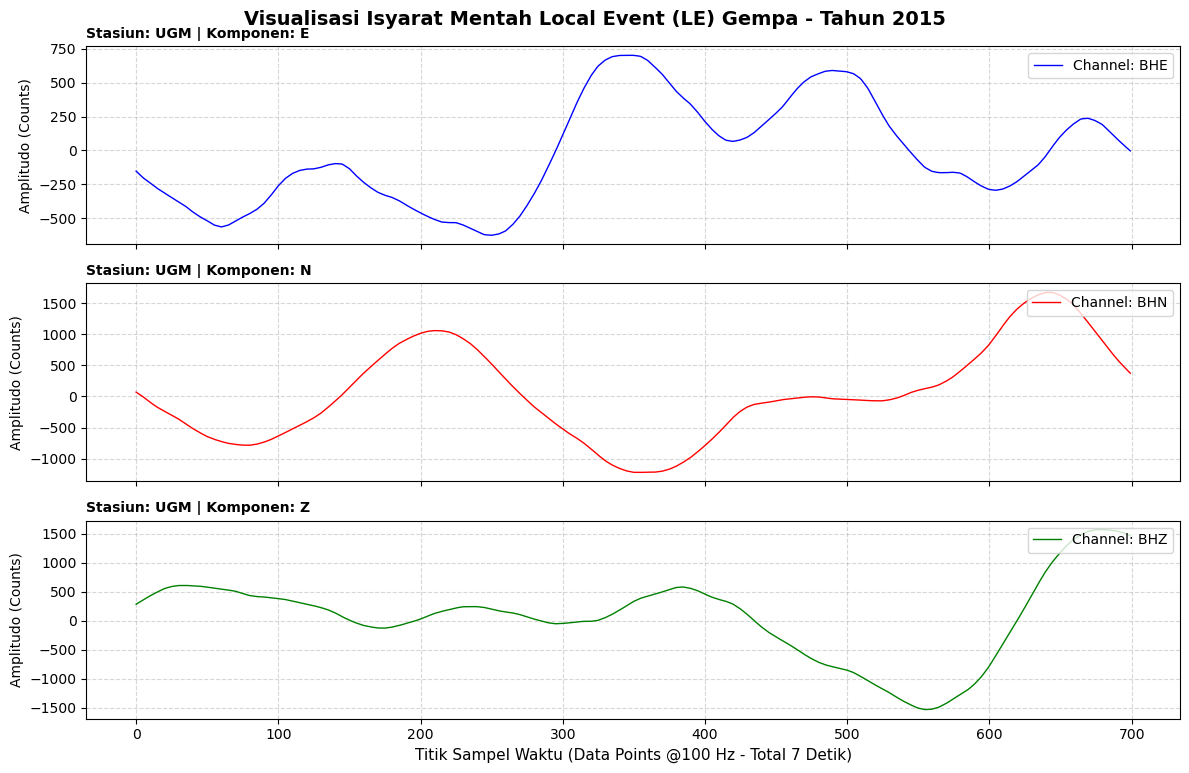

✅ Grafik sukses diproyeksikan ke layar Jupyter Notebook.


In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from obspy import read

# ==============================================================================
# 🎛️ PARAMETER SELEKSI SAMPEL DATA (Sesuaikan Jalur SSD Mac Anda)
# ==============================================================================
PATH_MANIFEST_CSV = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/dataset_manifest_event_only.csv'
TARGET_YEAR = "2015"

def visualisasikan_sampel_gempa_2015():
    print("="*80)
    print(f"🚀 STARTING: WAVEFORM VISUALIZER FOR YEAR {TARGET_YEAR}")
    print("="*80)
    
    if not os.path.exists(PATH_MANIFEST_CSV):
        print(f"❌ GALAT: File manifest CSV tidak ditemukan di: {PATH_MANIFEST_CSV}")
        return
        
    # Memuat database manifest CSV
    df = pd.read_csv(PATH_MANIFEST_CSV)
    
    # Filter manifest untuk mencari baris data yang berada di folder tahun 2015
    df_2015 = df[df['File_Path'].astype(str).str.contains(f"/{TARGET_YEAR}/")]
    
    if df_2015.empty:
        print(f"❌ GALAT: Belum ada data tahun {TARGET_YEAR} yang tercatat di manifest CSV.")
        print("💡 Solusi: Jalankan terlebih dahulu skrip splitter untuk tahun 2015 Anda.")
        return
        
    # Mengambil sampel baris pertama dari hasil filter tahun 2015
    sampel_row = df_2015.iloc[0]
    file_sample_path = sampel_row['File_Path']
    
    print(f"📋 Sampel Berkas Terpilih : {file_sample_path}")
    print(f"🏷️ Label Kategori        : {sampel_row['Category']} ({sampel_row['Label']})")
    print("-" * 80)
    
    if not os.path.exists(file_sample_path):
        print(f"❌ GALAT: File fisik .mseed tidak ditemukan di SSD: {file_sample_path}")
        return
        
    try:
        # Menerima dan membaca file pecahan 7 detik dari SSD
        st = read(file_sample_path)
        
        # Membuat kanvas grafik vertikal untuk 3 komponen (Z, N, E)
        fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
        colors = ['blue', 'red', 'green']
        
        print("⏳ Menghitung matriks amplitudo dan merancang grafik plot...")
        for idx, tr in enumerate(st):
            if idx >= 3: break  # Batasi hanya untuk 3 komponen orthogonal
            
            data_amplitudo = tr.data
            nama_channel = tr.stats.channel
            id_stasiun = tr.stats.station
            
            # Merancang grafik plot garis komponen seismik
            axes[idx].plot(data_amplitudo, color=colors[idx], linewidth=1.0, label=f"Channel: {nama_channel}")
            axes[idx].set_ylabel("Amplitudo (Counts)", fontsize=10)
            axes[idx].legend(loc="upper right")
            axes[idx].grid(True, linestyle='--', alpha=0.5)
            axes[idx].set_title(f"Stasiun: {id_stasiun} | Komponen: {nama_channel[-1]}", loc='left', fontsize=10, fontweight='bold')
            
        # Mengatur label sumbu X paling bawah (total 700 titik sampel)
        axes[2].set_xlabel("Titik Sampel Waktu (Data Points @100 Hz - Total 7 Detik)", fontsize=11)
        
        plt.suptitle(f"Visualisasi Isyarat Mentah Local Event (LE) Gempa - Tahun {TARGET_YEAR}", fontsize=14, fontweight='bold', y=0.96)
        plt.tight_layout()
        
        # Tampilkan grafik secara inline di halaman Jupyter Notebook Bapak
        plt.show()
        print("✅ Grafik sukses diproyeksikan ke layar Jupyter Notebook.")
        
    except Exception as e:
        print(f"❌ Gagal memvisualisasikan gelombang. Alasan: {str(e)}")

if __name__ == "__main__":
    visualisasikan_sampel_gempa_2015()

🚀 STARTING: WAVEFORM FILTER COMPARATOR FOR YEAR 2015
📂 Membaca berkas sampel: /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/event_3c_7s/2015/BMKG-20150726190135-001/GE_UGM_BMKG-20150726190135-001.mseed


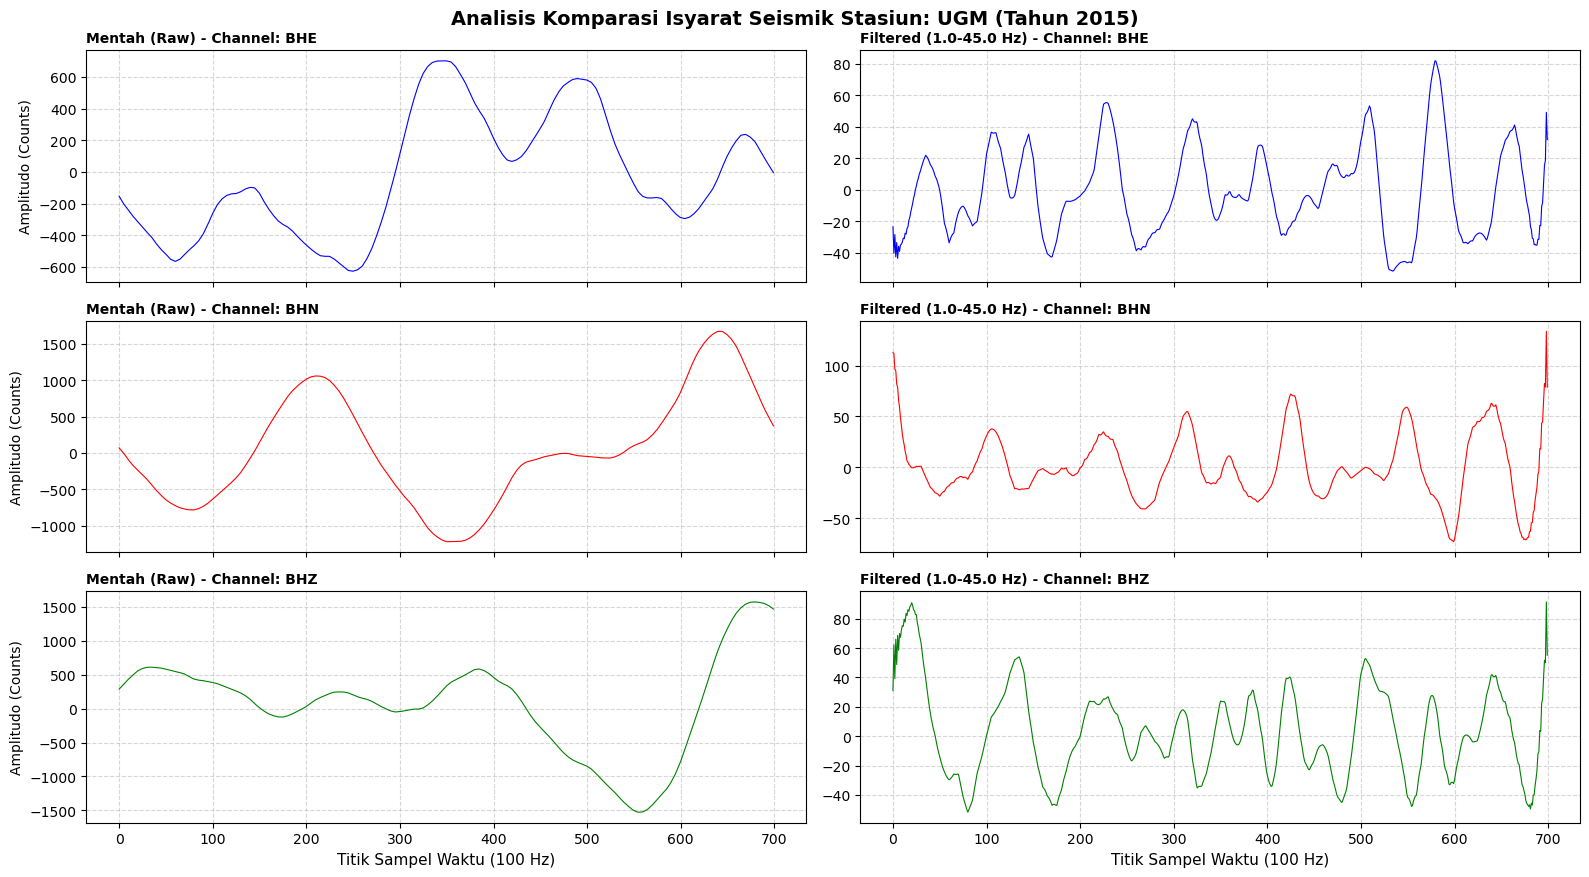

✅ Grafik perbandingan berhasil ditampilkan.
💡 Analisis: Perhatikan apakah fasa gelombang gempa transient menjadi lebih terlihat jelas pada kolom kanan (Filtered).


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from obspy import read

# ==============================================================================
# 🎛️ PARAMETER SELEKSI DATA & FILTER (Sesuaikan Jalur SSD Mac Anda)
# ==============================================================================
PATH_MANIFEST_CSV = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/dataset_manifest_event_only.csv'
TARGET_YEAR = "2015"

# Parameter filter geofisika untuk memunculkan fasa gempa lokal
FREQ_MIN = 1.0   # Batas bawah (Hz)
FREQ_MAX = 45.0  # Batas atas (Hz)

def jalankan_komparasi_filter():
    print("="*80)
    print(f"🚀 STARTING: WAVEFORM FILTER COMPARATOR FOR YEAR {TARGET_YEAR}")
    print("="*80)
    
    if not os.path.exists(PATH_MANIFEST_CSV):
        print(f"❌ GALAT: File manifest CSV tidak ditemukan.")
        return
        
    # Memuat manifest dan mengambil sampel baris pertama tahun 2015
    df = pd.read_csv(PATH_MANIFEST_CSV)
    df_2015 = df[df['File_Path'].astype(str).str.contains(f"/{TARGET_YEAR}/")]
    
    if df_2015.empty:
        print(f"❌ GALAT: Data tahun {TARGET_YEAR} tidak ditemukan di manifest CSV.")
        return
        
    file_sample_path = df_2015.iloc[0]['File_Path']
    print(f"📂 Membaca berkas sampel: {file_sample_path}")
    
    try:
        # 1. Muat Sinyal Mentah (Sama seperti kondisi di berkas image_03534d.png)
        st_raw = read(file_sample_path)
        
        # 2. Muat dan Terapkan Filter Bandpass pada Duplikat Sinyal
        st_filtered = st_raw.copy()
        st_filtered.filter(type='bandpass', freqmin=FREQ_MIN, freqmax=FREQ_MAX, corners=4, zerophase=True)
        
        # 3. Merancang Kanvas Grafik Komparasi (2 Kolom: Kiri Mentah vs Kanan Filter)
        fig, axes = plt.subplots(3, 2, figsize=(16, 9), sharex='col')
        colors = ['blue', 'red', 'green']
        
        for idx in range(3):
            if idx >= len(st_raw): break
            
            # Ekstrak komponen trace
            tr_raw = st_raw[idx]
            tr_filt = st_filtered[idx]
            
            # --- KOLOM KIRI: Sinyal Mentah (Raw Mode) ---
            axes[idx, 0].plot(tr_raw.data, color=colors[idx], linewidth=0.8)
            axes[idx, 0].set_ylabel("Amplitudo (Counts)")
            axes[idx, 0].grid(True, linestyle='--', alpha=0.5)
            axes[idx, 0].set_title(f"Mentah (Raw) - Channel: {tr_raw.stats.channel}", loc='left', fontsize=10, fontweight='bold')
            
            # --- KOLOM KANAN: Sinyal Hasil Filter Bandpass (1.0 - 45.0 Hz) ---
            axes[idx, 1].plot(tr_filt.data, color=colors[idx], linewidth=0.8)
            axes[idx, 1].grid(True, linestyle='--', alpha=0.5)
            axes[idx, 1].set_title(f"Filtered ({FREQ_MIN}-{FREQ_MAX} Hz) - Channel: {tr_filt.stats.channel}", loc='left', fontsize=10, fontweight='bold')
            
        # Label Sumbu X paling bawah
        axes[2, 0].set_xlabel("Titik Sampel Waktu (100 Hz)", fontsize=11)
        axes[2, 1].set_xlabel("Titik Sampel Waktu (100 Hz)", fontsize=11)
        
        plt.suptitle(f"Analisis Komparasi Isyarat Seismik Stasiun: {st_raw[0].stats.station} (Tahun {TARGET_YEAR})", fontsize=14, fontweight='bold', y=0.97)
        plt.tight_layout()
        plt.show()
        
        print("✅ Grafik perbandingan berhasil ditampilkan.")
        print("💡 Analisis: Perhatikan apakah fasa gelombang gempa transient menjadi lebih terlihat jelas pada kolom kanan (Filtered).")
        
    except Exception as e:
        print(f"❌ Gagal memproses visualisasi komparasi. Alasan: {str(e)}")
    print("="*80)

if __name__ == "__main__":
    jalankan_komparasi_filter()

In [12]:
import os
import gc
import glob
import numpy as np
import pandas as pd
from obspy import read, Stream, UTCDateTime
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER KONFIGURASI ADAPTASI STEAD (Sesuaikan Folder SSD Mac Anda)
# ==============================================================================
TARGET_YEAR = "2015"  # 🎯 Bapak bisa ganti tahun di sini untuk eksekusi bertahap berikutnya

INPUT_GABUNGAN_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/katalog_radar_dll/HYBRID_EARTHQUAKE_CATALOG_2001_2024.csv'
BASE_DATASET_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai'

# Mengarahkan output ke folder durasi penuh 60 detik standar STEAD
OUTPUT_EVENT_DIR = os.path.join(BASE_DATASET_DIR, 'event_3c_60s')
PATH_LABEL_CATALOG_CSV = os.path.join(BASE_DATASET_DIR, 'dataset_manifest_stead_compliant.csv')

# Parameter Spesifikasi Kunci Pola Data STEAD
TARGET_SAMPLING_RATE = 100.0   # Resample seragam ke 100 Hz
TARGET_DURATION_SEC = 60.0     # Wajib durasi panjang 60 detik (Standar STEAD)
EXPECTED_PTS = int(TARGET_DURATION_SEC * TARGET_SAMPLING_RATE)  # Mutlak wajib 6000 Titik

# Parameter Filter Geofisika STEAD (Berdasarkan Sukses Visualisasi Kolom Kanan)
FREQ_MIN_HZ = 1.0              # Batas bawah filter bandpass (Hz)
FREQ_MAX_HZ = 45.0             # Batas atas filter bandpass (Hz)
TAPER_PERCENTAGE = 0.05        # Redam riak ujung sinyal sebesar 5%

def filter_advanced_channel_band(st):
    """ Menyaring interferensi kode lokasi ganda atau multi-band sensor """
    if len(st) <= 3:
        return st
    bh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("BH")]
    if len(bh_traces) == 3: return Stream(traces=bh_traces)
    hh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("HH")]
    if len(hh_traces) == 3: return Stream(traces=hh_traces)
    st_fallback = Stream()
    components_seen = set()
    for tr in st:
        comp_letter = tr.stats.channel[-1].upper()
        if comp_letter not in components_seen:
            components_seen.add(comp_letter)
            st_fallback.append(tr)
        if len(st_fallback) == 3: break
    return st_fallback

def process_extract_stead_compliant(file_path, origin_time_str):
    """
    Fungsi memotong sinyal 3-komponen sepanjang 60 detik terfilter penuh sesuai standar STEAD
    """
    try:
        st_raw = read(file_path)
        
        # 🛡️ 1. Pembersihan Struktur Komponen (Wajib Lengkap 3 Komponen Orthogonal)
        st_master = filter_advanced_channel_band(st_raw)
        if len(st_master) != 3:
            del st_raw, st_master
            return None
            
        # 🛡️ 2. PIPA PRAPEMROSESAN DIGITAL GEOFISIKA LENGKAP (STEAD STYLE)
        for tr in st_master:
            tr.detrend(type='demean')
            tr.detrend(type='linear')
            
            # Aplikasi Taper dan Bandpass Filter untuk memunculkan fasa gelombang transient
            tr.taper(max_percentage=TAPER_PERCENTAGE, type='cosine')
            tr.filter(type='bandpass', freqmin=FREQ_MIN_HZ, freqmax=FREQ_MAX_HZ, corners=4, zerophase=True)
                
        # 🕒 3. PENETAPAN JANGKAR WAKTU STEAD: Dimulai 5 detik sebelum fasa gempa dari katalog tiba
        iso_time_str = origin_time_str.replace(" ", "T")
        t_origin = UTCDateTime(iso_time_str)
        
        # ─── 📑 EKSTRAKSI JENDELA PANJANG STEAD VIA NUMPY INTERPOLATOR ───
        st_stead = Stream()
        for tr in st_master:
            orig_data = tr.data
            orig_npts = tr.stats.npts
            orig_sr = tr.stats.sampling_rate
            
            if orig_npts == 0 or orig_sr <= 0:
                new_data = np.zeros(EXPECTED_PTS, dtype=np.float32)
            else:
                # Mengubah rentang sumbu matematika ke durasi penuh 60 detik standar STEAD
                actual_duration = orig_npts / orig_sr
                time_original = np.linspace(0, actual_duration, orig_npts)
                time_target = np.linspace(0, TARGET_DURATION_SEC, EXPECTED_PTS)
                
                # Interpolasi NumPy 1D kebal NaN untuk mematok ukuran array tepat 6000 titik
                new_data = np.interp(time_target, time_original, orig_data).astype(np.float32)
            
            tr_new = tr.copy()
            tr_new.data = new_data
            tr_new.stats.sampling_rate = TARGET_SAMPLING_RATE
            tr_new.stats.npts = EXPECTED_PTS
            st_stead.append(tr_new)
            
        if len(st_stead) != 3:
            del st_raw, st_master, st_stead
            return None

        # ─── 📦 4. Penulisan Berkas Fisik 60 Detik Terfilter ke SSD Mac ───
        relative_path = os.path.relpath(file_path, INPUT_GABUNGAN_DIR)
        final_mseed_path = os.path.join(OUTPUT_EVENT_DIR, relative_path)
        os.makedirs(os.path.dirname(final_mseed_path), exist_ok=True)
        st_stead.write(final_mseed_path, format="MSEED")
        
        records = [
            {"File_Path": final_mseed_path, "Category": "Earthquake", "Label": "LE"}
        ]
        del st_raw, st_master, st_stead
        return records
    except Exception:
        return None

def run_stead_compliant_pipeline():
    print("="*80)
    print(f"🚀 STARTING: YEARLY STEAD-COMPLIANT SPLITTER [YEAR: {TARGET_YEAR}] [60 SECONDS]")
    print("="*80)
    
    spesifik_tahun_dir = os.path.join(INPUT_GABUNGAN_DIR, TARGET_YEAR)
    if not os.path.exists(spesifik_tahun_dir):
        print(f"❌ GALAT: Folder tahun {TARGET_YEAR} tidak ditemukan di SSD.")
        return

    os.makedirs(BASE_DATASET_DIR, exist_ok=True)
        
    print(f"⏳ Memuat pangkalan data Katalog Master untuk memvalidasi tahun {TARGET_YEAR}...")
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    
    col_id = 'Event_ID'
    col_time = 'Time_UTC'
    
    # Filter tabel katalog master berdasarkan tahun target
    df_catalog_filtered = df_catalog[df_catalog[col_time].astype(str).str.contains(TARGET_YEAR)].copy()
    print(f"   • Total Event ID Valid di Katalog untuk tahun {TARGET_YEAR}: {len(df_catalog_filtered):,} kejadian.")
    
    # Map ke Python Dictionary untuk akselerasi loop pencarian waktu origin
    catalog_time_map = dict(zip(df_catalog_filtered[col_id].astype(str), df_catalog_filtered[col_time].astype(str)))
    del df_catalog, df_catalog_filtered
    gc.collect()
    
    print(f"📂 Menyisir folder SSD khusus untuk subfolder tahun: {TARGET_YEAR}...")
    search_path = os.path.join(spesifik_tahun_dir, "**", "*.mseed")
    all_files = glob.glob(search_path, recursive=True)
    total_files = len(all_files)
    
    print(f"✅ Terdata {total_files:,} berkas di dalam folder tahun {TARGET_YEAR}.")
    if total_files == 0:
        return
    
    chunk_records = []
    success_count = 0
    missing_catalog_count = 0
    
    with tqdm(total=total_files, unit="file", desc=f"STEAD Slicing {TARGET_YEAR}") as pbar:
        for idx, file_path in enumerate(all_files, 1):
            folder_event_id = os.path.basename(os.path.dirname(file_path))
            
            origin_time_str = catalog_time_map.get(str(folder_event_id), None)
            
            if origin_time_str is None:
                missing_catalog_count += 1
                pbar.update(1)
                continue
                
            # Jalankan pemotongan berstandar STEAD (60 detik, 3 Komponen Terfilter)
            result = process_extract_stead_compliant(file_path, origin_time_str)
            if result:
                success_count += 1
                chunk_records.extend(result)
                
            pbar.update(1)
            pbar.set_postfix({"STEAD_Valid": success_count, "Absen_Katalog": missing_catalog_count})
            
            if idx % 1000 == 0:
                if chunk_records:
                    df_chunk = pd.DataFrame(chunk_records)
                    df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                                    header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
                    chunk_records.clear()
                gc.collect()
                
    if chunk_records:
        df_chunk = pd.DataFrame(chunk_records)
        df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', 
                        header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
        chunk_records.clear()
        
    gc.collect()
    print("\n" + "="*60)
    print(f"🏁 PROSES SELESAI: TAHUN {TARGET_YEAR} SELESAI BERSTANDAR STEAD STANDARDS")
    print("="*60)
    print(f"✅ Total Berkas STEAD Berhasil Diproduksi : {success_count:,} file.")
    print(f"📦 Akumulasi Manifes CSV Tersimpan di     : {PATH_LABEL_CATALOG_CSV}")
    print("="*60)

if __name__ == "__main__":
    run_stead_compliant_pipeline()

🚀 STARTING: YEARLY STEAD-COMPLIANT SPLITTER [YEAR: 2015] [60 SECONDS]
⏳ Memuat pangkalan data Katalog Master untuk memvalidasi tahun 2015...
   • Total Event ID Valid di Katalog untuk tahun 2015: 6,351 kejadian.
📂 Menyisir folder SSD khusus untuk subfolder tahun: 2015...
✅ Terdata 2,147 berkas di dalam folder tahun 2015.


STEAD Slicing 2015:   0%|          | 0/2147 [00:00<?, ?file/s]/opt/homebrew/Caskroom/miniforge/base/envs/waveform/lib/python3.10/site-packages/obspy/signal/filter.py:87: UserWarning: Selected high corner frequency (45.0) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)
/opt/homebrew/Caskroom/miniforge/base/envs/waveform/lib/python3.10/site-packages/obspy/io/mseed/core.py:1034: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)
STEAD Slicing 2015: 100%|██████████| 2147/2147 [00:20<00:00, 107.10file/s, STEAD_Valid=2147, Absen_Katalog=0]



🏁 PROSES SELESAI: TAHUN 2015 SELESAI BERSTANDAR STEAD STANDARDS
✅ Total Berkas STEAD Berhasil Diproduksi : 2,147 file.
📦 Akumulasi Manifes CSV Tersimpan di     : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/dataset_manifest_stead_compliant.csv


🚀 STARTING: STEAD-COMPLIANT WAVEFORM VISUALIZER (60 SECONDS)
📋 Sampel Berkas Terpilih : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/event_3c_60s/2015/BMKG-20150726190135-001/GE_UGM_BMKG-20150726190135-001.mseed
🏷️ Label Kategori        : Earthquake (LE)
--------------------------------------------------------------------------------
⏳ Mengekstrak data matriks getaran dan merancang grafik plot...


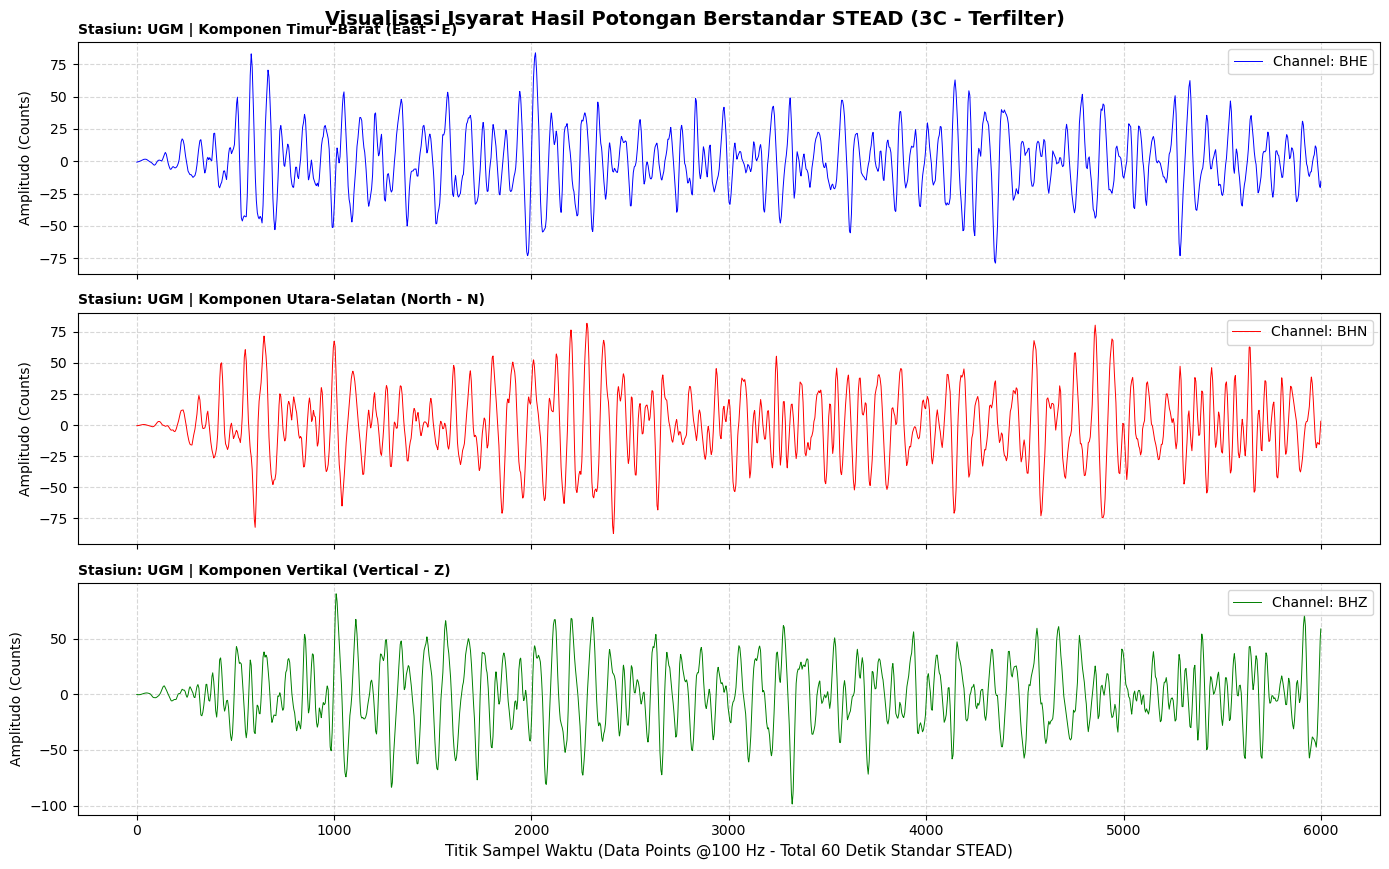

✅ Grafik berstandar STEAD berhasil diproyeksikan ke layar.


In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from obspy import read

# ==============================================================================
# 🎛️ PARAMETER JALUR DATA LOKAL (Sesuaikan Folder SSD Mac Anda)
# ==============================================================================
PATH_MANIFEST_CSV = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/dataset_manifest_stead_compliant.csv'

def visualisasikan_dataset_stead_compliant():
    print("="*80)
    print("🚀 STARTING: STEAD-COMPLIANT WAVEFORM VISUALIZER (60 SECONDS)")
    print("="*80)
    
    if not os.path.exists(PATH_MANIFEST_CSV):
        print(f"❌ GALAT: Berkas manifest CSV tidak ditemukan di: {PATH_MANIFEST_CSV}")
        return
        
    # Memuat pangkalan data manifest CSV
    df = pd.read_csv(PATH_MANIFEST_CSV)
    
    if df.empty:
        print("❌ GALAT: File manifest CSV kosong. Belum ada data terdaftar.")
        return
        
    # Mengambil sampel baris pertama dari manifest hasil pemrosesan STEAD
    sample_row = df.iloc[0]
    file_sample_path = sample_row['File_Path']
    
    print(f"📋 Sampel Berkas Terpilih : {file_sample_path}")
    print(f"🏷️ Label Kategori        : {sample_row['Category']} ({sample_row['Label']})")
    print("-" * 80)
    
    if not os.path.exists(file_sample_path):
        print(f"❌ GALAT: Berkas fisik .mseed tidak ditemukan di SSD: {file_sample_path}")
        return
        
    try:
        # Membaca berkas biner MiniSEED 60 detik dari SSD Mac
        st = read(file_sample_path)
        
        # Merancang layout kanvas bertingkat untuk 3 komponen orthogonal (E, N, Z)
        fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
        colors = ['blue', 'red', 'green']
        titles = ['Komponen Timur-Barat (East - E)', 'Komponen Utara-Selatan (North - N)', 'Komponen Vertikal (Vertical - Z)']
        
        print("⏳ Mengekstrak data matriks getaran dan merancang grafik plot...")
        for idx, tr in enumerate(st):
            if idx >= 3: break  # Batasi proteksi hanya untuk 3 saluran orthogonal
            
            data_amplitudo = tr.data
            nama_channel = tr.stats.channel
            id_stasiun = tr.stats.station
            
            # Memplot garis data getaran seismik terfilter
            axes[idx].plot(data_amplitudo, color=colors[idx], linewidth=0.7, label=f"Channel: {nama_channel}")
            axes[idx].set_ylabel("Amplitudo (Counts)", fontsize=10)
            axes[idx].legend(loc="upper right")
            axes[idx].grid(True, linestyle='--', alpha=0.5)
            axes[idx].set_title(f"Stasiun: {id_stasiun} | {titles[idx]}", loc='left', fontsize=10, fontweight='bold')
            
        # Mengatur konfigurasi sumbu X paling bawah (0 hingga 6000 titik sampel)
        axes[2].set_xlabel("Titik Sampel Waktu (Data Points @100 Hz - Total 60 Detik Standar STEAD)", fontsize=11)
        
        plt.suptitle("Visualisasi Isyarat Hasil Potongan Berstandar STEAD (3C - Terfilter)", fontsize=14, fontweight='bold', y=0.96)
        plt.tight_layout()
        
        # Memproyeksikan grafik secara inline di Jupyter Notebook
        plt.show()
        print("✅ Grafik berstandar STEAD berhasil diproyeksikan ke layar.")
        
    except Exception as e:
        print(f"❌ Gagal memvisualisasikan gelombang STEAD. Alasan: {str(e)}")
    print("="*80)

if __name__ == "__main__":
    visualisasikan_dataset_stead_compliant()

In [14]:
import os
import pandas as pd
from obspy import read, UTCDateTime

# ==============================================================================
# 🎛️ PARAMETER INVESTIGASI JALUR DATA (Sesuaikan Folder SSD Mac Anda)
# ==============================================================================
INPUT_GABUNGAN_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/katalog_radar_dll/HYBRID_EARTHQUAKE_CATALOG_2001_2024.csv'
TARGET_YEAR = "2015"

def cek_ketersediaan_data_pra_event():
    print("="*80)
    print("🚀 STARTING: PRE-EARTHQUAKE NOISE DATA AVAILABILITY CHECKER")
    print("="*80)
    
    if not os.path.exists(PATH_KATALOG_MASTER):
        print(f"❌ GALAT: File katalog master tidak ditemukan di: {PATH_KATALOG_MASTER}")
        return
        
    try:
        # Memuat pangkalan data katalog master
        df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
        df_filtered = df_catalog[df_catalog['Time_UTC'].astype(str).str.contains(TARGET_YEAR)]
        
        if df_filtered.empty:
            print(f"❌ GALAT: Tidak ada data kejadian untuk tahun {TARGET_YEAR} di katalog.")
            return
            
        # Cari file .mseed pertama di folder SSD untuk sampel uji coba
        search_path = os.path.join(INPUT_GABUNGAN_DIR, TARGET_YEAR, "**", "*.mseed")
        import glob
        all_files = glob.glob(search_path, recursive=True)
        
        if not all_files:
            print(f"❌ GALAT: Tidak ditemukan file fisik .mseed di folder SSD tahun {TARGET_YEAR}.")
            return
            
        # Ambil sampel file mseed pertama untuk dibedah isi headernya
        sample_file = all_files[0]
        folder_event_id = os.path.basename(os.path.dirname(sample_file))
        
        # Ambil waktu origin gempa dari katalog pasangannya
        row_match = df_filtered[df_filtered['Event_ID'].astype(str) == str(folder_event_id)]
        if row_match.empty:
            print(f"⚠️ Sampel file {folder_event_id} tidak terdaftar di katalog tahun {TARGET_YEAR}.")
            return
            
        origin_time_str = row_match['Time_UTC'].values[0]
        t_origin = UTCDateTime(origin_time_str.replace(" ", "T"))
        
        # Baca header fisik file mseed menggunakan ObsPy
        st = read(sample_file)
        t_start_file = st[0].stats.starttime
        
        # 🔥 HITUNG KETERSEDIAAN DATA SEBELUM GEMPA
        selisih_detik = t_origin - t_start_file
        
        print(f"📋 Analisis Berkas Sampel : {sample_file}")
        print(f"   • Waktu Awal Rekaman File (Start) : {t_start_file}")
        print(f"   • Waktu Kejadian Gempa (Origin)   : {t_origin}")
        print(f"   • Ruang Kosong Tersedia Sebelum Gempa : {selisih_detik:.2f} detik")
        print("-" * 80)
        
        if selisih_detik >= 60.0:
            print("✅ KESIMPULAN: DATA TERSEDIA! File Anda memiliki ruang lebih dari 60 detik")
            print("   sebelum gempa terjadi, sehingga segmen NOISE (NO) pra-event aman dipotong!")
        else:
            print("⚠️ KESIMPULAN: DATA TIDAK CUKUP UTUH!")
            print(f"   File ini hanya memiliki {selisih_detik:.2f} detik data pra-event.")
            print("   Jika dipaksa potong 60 detik, bagian depannya akan ditambal angka 0 (Zero-Padding).")
            
    except Exception as e:
        print(f"❌ Gagal menjalankan inspeksi data. Alasan: {str(e)}")
    print("="*80)

if __name__ == "__main__":
    cek_ketersediaan_data_pra_event()

🚀 STARTING: PRE-EARTHQUAKE NOISE DATA AVAILABILITY CHECKER
📋 Analisis Berkas Sampel : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/2015/BMKG-20150726190135-001/GE_UGM_BMKG-20150726190135-001.mseed
   • Waktu Awal Rekaman File (Start) : 2015-07-26T19:01:20.019538Z
   • Waktu Kejadian Gempa (Origin)   : 2015-07-26T00:00:00.000000Z
   • Ruang Kosong Tersedia Sebelum Gempa : -68480.02 detik
--------------------------------------------------------------------------------
⚠️ KESIMPULAN: DATA TIDAK CUKUP UTUH!
   File ini hanya memiliki -68480.02 detik data pra-event.
   Jika dipaksa potong 60 detik, bagian depannya akan ditambal angka 0 (Zero-Padding).


In [15]:
import os
import gc
import glob
import re
import numpy as np
import pandas as pd
from obspy import read, Stream, UTCDateTime
from tqdm import tqdm

# ==============================================================================
# 🎛️ PARAMETER KONFIGURASI DATA 7 DETIK SEIMBANG (Sesuaikan Folder SSD Mac Anda)
# ==============================================================================
TARGET_YEAR = "2015"  

INPUT_GABUNGAN_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'
PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/katalog_radar_dll/HYBRID_EARTHQUAKE_CATALOG_2001_2024.csv'
BASE_DATASET_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai'

# Folder Output Kompak 7 Detik untuk Sinyal Gempa (LE) dan Noise Latar (NO)
OUTPUT_EVENT_DIR = os.path.join(BASE_DATASET_DIR, 'event_3c_7s')
OUTPUT_NOISE_DIR = os.path.join(BASE_DATASET_DIR, 'noise_3c_7s')
PATH_LABEL_CATALOG_CSV = os.path.join(BASE_DATASET_DIR, 'dataset_manifest_balanced_7s.csv')

# 🔥 MODIFIKASI TARGET: Durasi disamakan kompak 7 detik (700 Titik Sampel @100 Hz)
TARGET_SAMPLING_RATE = 100.0   
TARGET_DURATION_SEC = 7.0      
EXPECTED_PTS = int(TARGET_DURATION_SEC * TARGET_SAMPLING_RATE)  

# Parameter Penapisan Bandpass Spektral Bersih
FREQ_MIN_HZ = 1.0              
FREQ_MAX_HZ = 45.0             
TAPER_PERCENTAGE = 0.05        

def filter_advanced_channel_band(st):
    """ Menyaring interferensi kode lokasi ganda atau multi-band sensor """
    if len(st) <= 3: return st
    bh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("BH")]
    if len(bh_traces) == 3: return Stream(traces=bh_traces)
    hh_traces = [tr for tr in st if tr.stats.channel.upper().startswith("HH")]
    if len(hh_traces) == 3: return Stream(traces=hh_traces)
    st_fallback = Stream()
    components_seen = set()
    for tr in st:
        comp_letter = tr.stats.channel[-1].upper()
        if comp_letter not in components_seen:
            components_seen.add(comp_letter)
            st_fallback.append(tr)
        if len(st_fallback) == 3: break
    return st_fallback

def resample_matrix_numpy(tr, target_duration):
    """ Ekstraktor matriks linier NumPy untuk mengunci seragam ukuran 700 titik sampel """
    orig_data = tr.data
    orig_npts = tr.stats.npts
    orig_sr = tr.stats.sampling_rate
    
    if orig_npts == 0 or orig_sr <= 0:
        return np.zeros(EXPECTED_PTS, dtype=np.float32)
        
    actual_duration = orig_npts / orig_sr
    time_original = np.linspace(0, actual_duration, orig_npts)
    time_target = np.linspace(0, target_duration, EXPECTED_PTS)
    
    return np.interp(time_target, time_original, orig_data).astype(np.float32)

def ekstrak_waktu_dari_nama_folder(folder_name):
    """ Menggunakan regex untuk mengekstrak string waktu sejati dari nama folder """
    match = re.search(r'\d{8}\d{6}', folder_name)
    if match:
        s = match.group(0)
        return UTCDateTime(f"{s[0:4]}-{s[4:6]}-{s[6:8]}T{s[8:10]}:{s[10:12]}:{s[12:14]}")
    return None

def slice_and_filter_block_numpy(st_master, start_time, end_time, duration_val):
    """ Memotong rentang waktu dan memproses penapisan bandpass filter """
    st_slice = st_master.copy()
    st_slice.trim(starttime=start_time, endtime=end_time, pad=True, fill_value=0)
    
    st_output = Stream()
    for tr in st_slice:
        tr.detrend(type='demean')
        tr.detrend(type='linear')
        tr.taper(max_percentage=TAPER_PERCENTAGE, type='cosine')
        tr.filter(type='bandpass', freqmin=FREQ_MIN_HZ, freqmax=FREQ_MAX_HZ, corners=4, zerophase=True)
        
        # Jaminan dimensi tensor seragam via NumPy (700 titik sampel)
        tr.data = resample_matrix_numpy(tr, duration_val)
        tr.stats.sampling_rate = TARGET_SAMPLING_RATE
        tr.stats.npts = EXPECTED_PTS
        st_output.append(tr)
    return st_output if len(st_output) == 3 else None

def process_extract_balanced_7s_pairs(file_path):
    """ Pipa pemotong berpasangan LE dan NO seimbang berdurasi 7 detik murni """
    try:
        st_raw = read(file_path)
        st_master = filter_advanced_channel_band(st_raw)
        if len(st_master) != 3:
            del st_raw, st_master
            return None
            
        folder_name = os.path.basename(os.path.dirname(file_path))
        t_event_sejati = ekstrak_waktu_dari_nama_folder(folder_name)
        t_start_file = st_master[0].stats.starttime
        
        if t_event_sejati is None:
            del st_raw, st_master
            return None
            
        # ─── 📑 SEGMEN 1: JENDELA GEMPA (LE) -> 7 Detik Sejak Waktu Kejadian ───
        st_le = slice_and_filter_block_numpy(st_master, t_event_sejati, t_event_sejati + TARGET_DURATION_SEC, TARGET_DURATION_SEC)
        
        # ─── 📑 SEGMEN 2: JENDELA NOISE (NO) -> 7 Detik Awal Rekaman Berkas (Pra-Event) ───
        st_no = slice_and_filter_block_numpy(st_master, t_start_file, t_start_file + TARGET_DURATION_SEC, TARGET_DURATION_SEC)
        
        if st_le is None or st_no is None:
            del st_raw, st_master, st_le, st_no
            return None
            
        relative_path = os.path.relpath(file_path, INPUT_GABUNGAN_DIR)
        final_le_path = os.path.join(OUTPUT_EVENT_DIR, relative_path)
        final_no_path = os.path.join(OUTPUT_NOISE_DIR, relative_path)
        
        os.makedirs(os.path.dirname(final_le_path), exist_ok=True)
        os.makedirs(os.path.dirname(final_no_path), exist_ok=True)
        
        st_le.write(final_le_path, format="MSEED")
        st_no.write(final_no_path, format="MSEED")
        
        records = [
            {"File_Path": final_le_path, "Category": "Earthquake", "Label": "LE"},
            {"File_Path": final_no_path, "Category": "Noise", "Label": "NO"}
        ]
        del st_raw, st_master, st_le, st_no
        return records
    except Exception:
        return None

def run_balanced_7s_pipeline():
    print("="*80)
    print(f"🚀 STARTING: BALANCED 7-SECONDS LE/NO PAIR SPLITTER [YEAR: {TARGET_YEAR}]")
    print("="*80)
    
    spesifik_tahun_dir = os.path.join(INPUT_GABUNGAN_DIR, TARGET_YEAR)
    if not os.path.exists(spesifik_tahun_dir): return

    os.makedirs(OUTPUT_EVENT_DIR, exist_ok=True)
    os.makedirs(OUTPUT_NOISE_DIR, exist_ok=True)
    if os.path.exists(PATH_LABEL_CATALOG_CSV): os.remove(PATH_LABEL_CATALOG_CSV)
        
    print(f"⏳ Memuat pangkalan data Katalog Master untuk validasi ID...")
    df_catalog = pd.read_csv(PATH_KATALOG_MASTER)
    df_catalog_filtered = df_catalog[df_catalog['Time_UTC'].astype(str).str.contains(TARGET_YEAR)].copy()
    valid_id_set = set(df_catalog_filtered['Event_ID'].astype(str).unique())
    del df_catalog, df_catalog_filtered
    gc.collect()
    
    all_files = glob.glob(os.path.join(spesifik_tahun_dir, "**", "*.mseed"), recursive=True)
    total_files = len(all_files)
    print(f"✅ Terdata {total_files:,} berkas di folder tahun {TARGET_YEAR}.")
    
    success_pairs = 0
    chunk_records = []
    
    with tqdm(total=total_files, unit="file", desc="Pair Slicing 7s") as pbar:
        for idx, file_path in enumerate(all_files, 1):
            folder_event_id = os.path.basename(os.path.dirname(file_path))
            
            if str(folder_event_id) not in valid_id_set:
                pbar.update(1)
                continue
                
            result = process_extract_balanced_7s_pairs(file_path)
            if result:
                success_pairs += 1
                chunk_records.extend(result)
                
            pbar.update(1)
            pbar.set_postfix({"Paired_Success": success_pairs})
            
            if idx % 500 == 0 and chunk_records:
                df_chunk = pd.DataFrame(chunk_records)
                df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
                chunk_records.clear()
                gc.collect()
                
    if chunk_records:
        df_chunk = pd.DataFrame(chunk_records)
        df_chunk.to_csv(PATH_LABEL_CATALOG_CSV, mode='a', header=not os.path.exists(PATH_LABEL_CATALOG_CSV), index=False)
        chunk_records.clear()
        
    print("\n" + "="*60)
    print(f"🏁 PROSES SELESAI: EKSTRAKSI BERPASANGAN COMPACT 7 DETIK SUKSES")
    print("="*60)
    print(f"✅ Total Pasangan Berhasil Dikunci : {success_pairs:,} pasang ({success_pairs * 2:,} file 7 detik total).")
    print(f"📦 Manifes CSV Hasil Slicing 7s    : {PATH_LABEL_CATALOG_CSV}")
    print("="*60)

if __name__ == "__main__":
    run_balanced_7s_pipeline()

🚀 STARTING: BALANCED 7-SECONDS LE/NO PAIR SPLITTER [YEAR: 2015]
⏳ Memuat pangkalan data Katalog Master untuk validasi ID...
✅ Terdata 2,147 berkas di folder tahun 2015.


Pair Slicing 7s:   0%|          | 0/2147 [00:00<?, ?file/s]/opt/homebrew/Caskroom/miniforge/base/envs/waveform/lib/python3.10/site-packages/obspy/signal/filter.py:87: UserWarning: Selected high corner frequency (45.0) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)
/opt/homebrew/Caskroom/miniforge/base/envs/waveform/lib/python3.10/site-packages/obspy/io/mseed/core.py:1034: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)
Pair Slicing 7s: 100%|██████████| 2147/2147 [00:29<00:00, 73.28file/s, Paired_Success=2147]


🏁 PROSES SELESAI: EKSTRAKSI BERPASANGAN COMPACT 7 DETIK SUKSES
✅ Total Pasangan Berhasil Dikunci : 2,147 pasang (4,294 file 7 detik total).
📦 Manifes CSV Hasil Slicing 7s    : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/dataset_manifest_balanced_7s.csv


🚀 STARTING: BALANCED 7-SECONDS PAIR WAVEFORM VISUALIZER
📂 Menginvestigasi File LE : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/event_3c_7s/2015/BMKG-20150726190135-001/GE_UGM_BMKG-20150726190135-001.mseed
📂 Menginvestigasi File NO : /Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/noise_3c_7s/2015/BMKG-20150726190135-001/GE_UGM_BMKG-20150726190135-001.mseed
--------------------------------------------------------------------------------
⏳ Memproses matriks amplitudo dan memproyeksikan grafik...


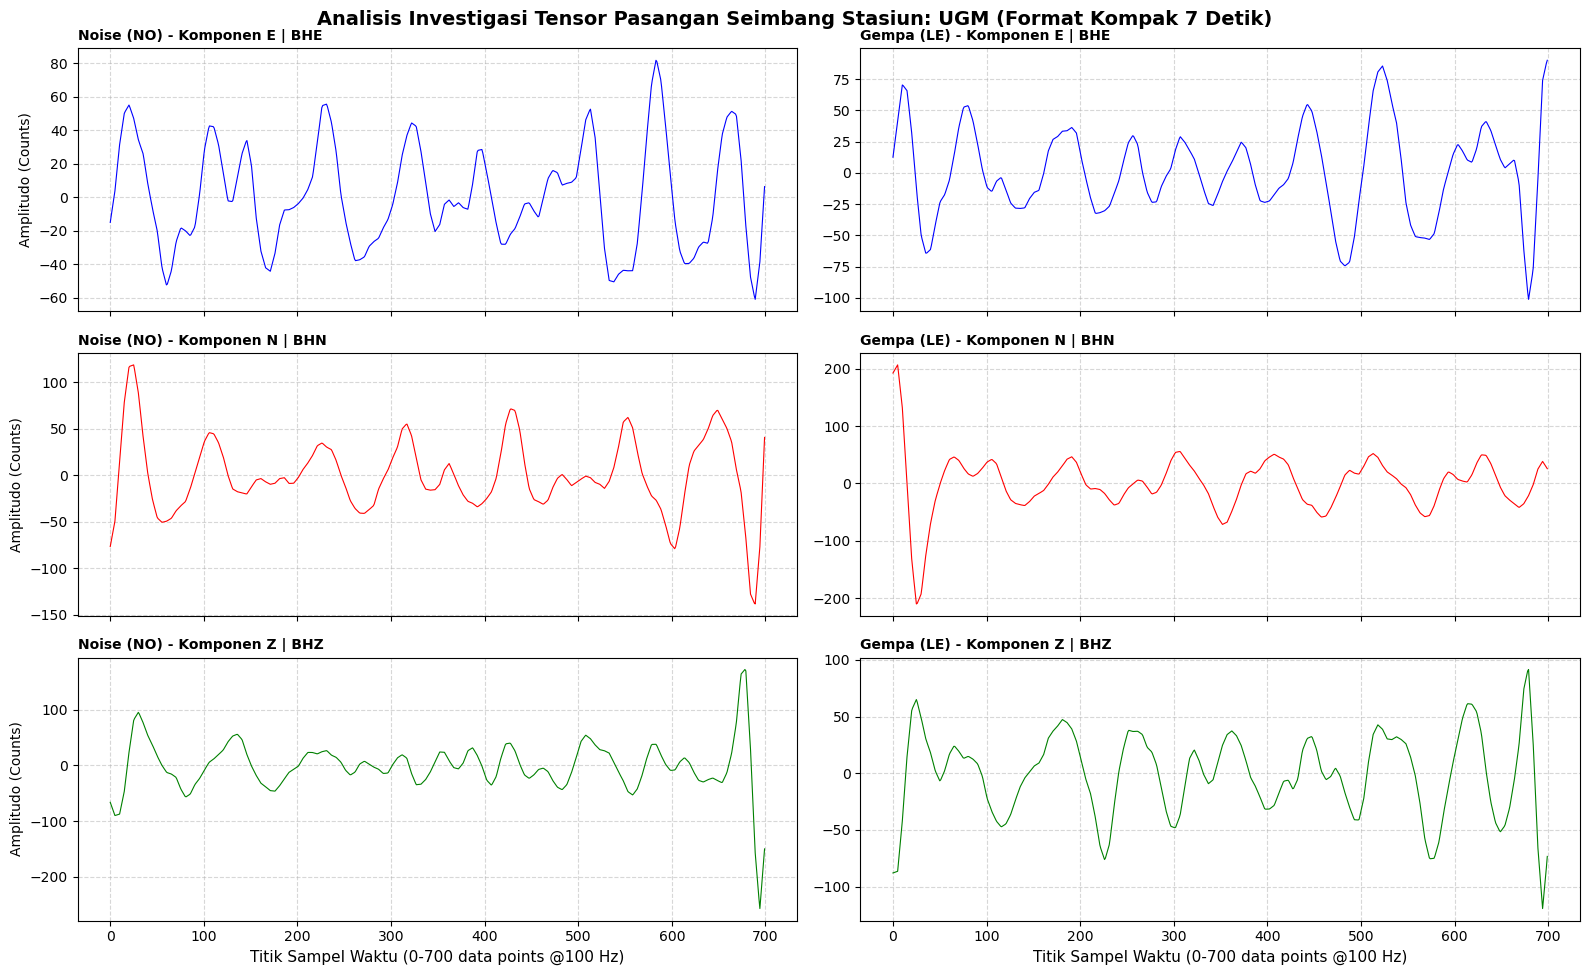

✅ Grafik investigasi pasangan 7 detik berhasil dirender di layar.


In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from obspy import read

# ==============================================================================
# 🎛️ PARAMETER JALUR DATA SEIMBANG (Sesuaikan Folder SSD Mac Anda)
# ==============================================================================
PATH_MANIFEST_CSV = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/dataset_ai/dataset_manifest_balanced_7s.csv'

def investigasi_dan_visualisasi_7s():
    print("="*80)
    print("🚀 STARTING: BALANCED 7-SECONDS PAIR WAVEFORM VISUALIZER")
    print("="*80)
    
    if not os.path.exists(PATH_MANIFEST_CSV):
        print(f"❌ GALAT: File manifest CSV tidak ditemukan di: {PATH_MANIFEST_CSV}")
        return
        
    # Muat manifes menggunakan pandas
    df = pd.read_csv(PATH_MANIFEST_CSV)
    
    # Cari entri data untuk stasiun UGM sebagai sampel investigasi utama
    df_ugm = df[df['File_Path'].astype(str).str.contains('UGM')].copy()
    
    if df_ugm.empty:
        # Fallback jika stasiun UGM tidak ada pada baris awal manifest, ambil baris pertama saja
        df_ugm = df.copy()
        
    try:
        # Isolasi jalur file LE dan NO yang berpasangan
        df_le = df_ugm[df_ugm['Label'] == 'LE']
        df_no = df_ugm[df_ugm['Label'] == 'NO']
        
        if df_le.empty or df_no.empty:
            print("❌ GALAT: Pasangan LE dan NO tidak lengkap di dalam manifest.")
            return
            
        path_file_le = df_le.iloc[0]['File_Path']
        path_file_no = df_no.iloc[0]['File_Path']
        
        print(f"📂 Menginvestigasi File LE : {path_file_le}")
        print(f"📂 Menginvestigasi File NO : {path_file_no}")
        print("-" * 80)
        
        # Membaca data gelombang dari SSD Mac Bapak
        st_le = read(path_file_le)
        st_no = read(path_file_no)
        
        # Membuat kanvas komparasi (3 Baris Komponen, 2 Kolom Kategori)
        fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
        colors = ['blue', 'red', 'green']
        components = ['E', 'N', 'Z']
        
        print("⏳ Memproses matriks amplitudo dan memproyeksikan grafik...")
        for idx in range(3):
            # --- KOLOM KIRI: Visualisasi Noise Latar (NO) 7 Detik ---
            data_no = st_no[idx].data
            axes[idx, 0].plot(data_no, color=colors[idx], linewidth=0.8)
            axes[idx, 0].set_ylabel("Amplitudo (Counts)", fontsize=10)
            axes[idx, 0].grid(True, linestyle='--', alpha=0.5)
            axes[idx, 0].set_title(f"Noise (NO) - Komponen {components[idx]} | {st_no[idx].stats.channel}", loc='left', fontsize=10, fontweight='bold')
            
            # --- KOLOM KANAN: Visualisasi Gempa Lokal (LE) 7 Detik ---
            data_le = st_le[idx].data
            axes[idx, 1].plot(data_le, color=colors[idx], linewidth=0.8)
            axes[idx, 1].grid(True, linestyle='--', alpha=0.5)
            axes[idx, 1].set_title(f"Gempa (LE) - Komponen {components[idx]} | {st_le[idx].stats.channel}", loc='left', fontsize=10, fontweight='bold')
            
        # Memberikan label sumbu waktu di baris paling bawah
        axes[2, 0].set_xlabel("Titik Sampel Waktu (0-700 data points @100 Hz)", fontsize=11)
        axes[2, 1].set_xlabel("Titik Sampel Waktu (0-700 data points @100 Hz)", fontsize=11)
        
        stasiun_id = st_le[0].stats.station
        plt.suptitle(f"Analisis Investigasi Tensor Pasangan Seimbang Stasiun: {stasiun_id} (Format Kompak 7 Detik)", fontsize=14, fontweight='bold', y=0.97)
        plt.tight_layout()
        plt.show()
        
        print("✅ Grafik investigasi pasangan 7 detik berhasil dirender di layar.")
        
    except Exception as e:
        print(f"❌ Gagal melakukan investigasi visual. Alasan: {str(e)}")

if __name__ == "__main__":
    investigasi_dan_visualisasi_7s()